In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"

import torch
import matplotlib.pyplot as plt
import numpy as np
import cv2
import gc
from torchviz import make_dot
from sklearn.datasets import make_moons
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets, transforms, utils
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from torch.utils.data import DataLoader, TensorDataset


%matplotlib inline

# Agenda

1. [Math behind Gradient Descent](#Math)
2. [SGD](#SGD) 
3. [SGD Modifications](#SGD_Modifications)
4. [RMSProp](#RMSProp)
5. [Adam](#Adam)
6. [RAdam](#RAdam)

# Resources

- [Chat with ChatGPT](https://chatgpt.com/share/68bdd269-05d0-8003-931c-cd2530454aee)
- [Gradient Descent, Stochastic Optimization, and Other Tales](https://arxiv.org/pdf/2205.00832)
- [lecture notes by G. Hinton](https://www.cs.toronto.edu/~tijmen/csc321/slides/lecture_slides_lec6.pdf)
- [An overview of gradient descent optimization algorithms](https://arxiv.org/pdf/1609.04747)
- [Generating Sequences With Recurrent Neural Networks](https://arxiv.org/pdf/1308.0850)
- [ON THE VARIANCE OF THE ADAPTIVE LEARNING RATE AND BEYOND](https://arxiv.org/pdf/1908.03265)
- [Adam: A Method for Stochastic Optimization](https://arxiv.org/abs/1412.6980)

<a id='Math'></a>
# Math behind Gradient Descent

<img src="images/anyone_knows_adam.jpeg" alt="Adam Meme" width="500"/>

## Gradient Descent by Calculus

We have loss function (in which we can write down the whole Neural Network) - $L(x) \in \mathbb{R}$

Now we have to find such a direction ($\Delta x_t$) from current point ($x_t$) that $L(x_t + \Delta x_t) \leq L(x_t)$. Where our next point will be: $x_{t+1} = x_t + \Delta x_t$ 

Calculus informs us of the variation in the objective function $L(x)$ as follows:

$$
\Delta L(x) \approx 
\frac{\partial L}{\partial x_1} \Delta x_1 +
\frac{\partial L}{\partial x_2} \Delta x_2 + \dots +
\frac{\partial L}{\partial x_d} \Delta x_d
$$

Let's set $\Delta x$ and $\nabla L(x)$

$$
\Delta x = [\Delta x_1, \Delta x_2, \dots, \Delta x_d]^\top
$$  


$$
\nabla L(x) = \frac{\partial L(x)}{\partial x} =
\begin{bmatrix} 
\frac{\partial L}{\partial x_1}, \frac{\partial L}{\partial x_2}, \dots, \frac{\partial L}{\partial x_d}
\end{bmatrix}^\top
$$  

So we get

$$
\Delta L(x) \approx 
\frac{\partial L}{\partial x_1} \Delta x_1 +
\frac{\partial L}{\partial x_2} \Delta x_2 + \dots +
\frac{\partial L}{\partial x_d} \Delta x_d
= \nabla L(x)^\top \Delta x
$$

In the context of descent, our objective is to ensure that $\Delta L(x)$ is negative.  
This condition ensures that a step  

$$
x_{t+1} = x_t + \Delta x_t
$$  

(from $t-th$ iteration to $(t+1)-th$ iteration) results in a decrease of the loss function  

$$
L(x_{t+1}) = L(x_t) + \Delta L(x_t),
$$  

given that $\Delta L(x_t) \leq 0$.  

It can be demonstrated that if the update step is defined as  

$$
\Delta x_t = -\eta \nabla L(x_t),
$$  

where $\eta$ is the learning rate, the following relationship holds:

$$
\Delta L(x_t) \approx 
\nabla L(x_t)^\top \Delta x_t
= -\eta \| \nabla L(x_t) \|_2^2 \leq 0
$$

To be precise, $\Delta L(x_t) < 0$ in the above equation; otherwise, we would have reached the optimal point with zero gradients.  
This analysis confirms the validity of gradient descent.

The update rule for the next parameter $x_{t+1}$ is given by:

$$
x_{t+1} = x_t - \eta \nabla L(x_t).
$$

If $L$ is differentiable, the negative gradient defines a descent direction whenever

$$
\nabla L(x_t) \neq 0.
$$

For a sufficiently small learning rate, the objective function decreases locally.

Under additional smoothness and convexity assumptions, gradient descent has convergence guarantees toward a global minimum.

In the non-convex case, gradient descent generally converges toward stationary points, which may include local minima or saddle points.

---

### Remark: Descent Condition

Let $d_t \in \mathbb{R}^d \setminus \{0\}$ be a search direction and let $\eta > 0$ be the step size.

According to the first-order Taylor approximation,

$$
L(x_t + \eta d_t) - L(x_t)
\approx
\eta \nabla L(x_t)^\top d_t.
$$

To obtain a decrease in the loss function, we want

$$
L(x_t + \eta d_t) < L(x_t).
$$

Since $\eta > 0$, it is sufficient to require

$$
\boxed{
\nabla L(x_t)^\top d_t < 0
}
$$

This is called the **descent condition**.

For gradient descent, we choose

$$
d_t = -\nabla L(x_t).
$$

Then

$$
\nabla L(x_t)^\top d_t
=
-\nabla L(x_t)^\top \nabla L(x_t)
=
-\|\nabla L(x_t)\|_2^2 < 0,
$$

assuming

$$
\nabla L(x_t) \neq 0.
$$

Therefore, the negative gradient is always a descent direction whenever the gradient is non-zero.

Note that the strict inequality

$$
\nabla L(x_t)^\top d_t < 0
$$

is important. If

$$
\nabla L(x_t)^\top d_t = 0,
$$

the first-order Taylor term does not tell us whether the loss increases or decreases, and higher-order terms become important.


> **CHECK**: Are "Chips" Convex ???


<img src="images/gradient_chips.jpg" alt="Gradient Chips" width="500"/>

### Definition (Convex Functions)  
A function $f : \mathbb{S} \to \mathbb{R}$ defined on a convex set $\mathbb{S} \subseteq \mathbb{R}^n$ is called **convex** if  
$$f(\lambda x + (1-\lambda) y) \leq \lambda f(x) + (1-\lambda) f(y),$$
where $x, y \in \mathbb{S}$, and $\lambda \in [0,1]$.  

The function $f$ is called **strictly convex** if  
$$f(\lambda x + (1-\lambda) y) < \lambda f(x) + (1-\lambda) f(y),$$
where $x \neq y \in \mathbb{S}$, and $\lambda \in (0,1)$.

> **PROVE**: Based on the definition, prove that the  global minimum will be always the local one (if it exists)

<a id='SGD'></a>
# SGD

## Gradient Descent Variants

Gradient descent is a way to minimize an objective function $J(\theta)$ parameterized by a model’s parameters $\theta \in \mathbb{R}^d$ by updating the parameters in the opposite direction of the gradient $\nabla_\theta J(\theta)$.  
The learning rate $\eta$ determines the size of the steps we take to reach a (local) minimum.  

There are three common variants of gradient descent, which differ in how much data they use to compute the gradient.  

---

### 1. Batch Gradient Descent
**Update rule:**
$ \theta = \theta - \eta \nabla_\theta J(\theta) $

- Computes the gradient of the cost function w.r.t. parameters $\theta$ **over the entire dataset**.  
- Each update requires a full pass over the training data.  
- Converges to the **global minimum** for convex functions and to a **local minimum** for non-convex functions.  
- Computationally expensive and not feasible for very large datasets.  

---

### 2. Stochastic Gradient Descent (SGD)
**Update rule:**
$ \theta = \theta - \eta \nabla_\theta J(\theta; x^{(i)}, y^{(i)}) $

- Updates parameters **per single training example** $(x^{(i)}, y^{(i)})$.  
- Much faster, allows **online learning** (process data one by one).  
- Updates are noisy → the loss fluctuates but may help escape shallow local minima.  
- With a decreasing learning rate schedule, SGD converges similarly to batch gradient descent.  

---

### 3. Mini-Batch Gradient Descent
**Update rule:**
$ \theta = \theta - \eta \nabla_\theta J(\theta; x^{(i:i+n)}, y^{(i:i+n)}) $

- Uses a **small batch of $n$ samples** instead of the full dataset or a single sample.  
- Combines benefits of batch and stochastic GD:
  - More stable convergence than SGD.  
  - More efficient than full batch due to vectorized operations.  
- Typical mini-batch sizes: 32–256.  
- **Default choice** when training neural networks.  

---

### Summary

| Variant                  | Data per update        | Pros                                        | Cons                                       |
|--------------------------|------------------------|---------------------------------------------|--------------------------------------------|
| Batch GD                 | Full dataset           | Stable convergence, exact gradient           | Very slow, not scalable                     |
| Stochastic GD            | One sample             | Fast, online learning, escapes local minima  | Noisy updates, harder to converge precisely |
| Mini-Batch GD            | Small batch (32–256)   | Efficient, stable, GPU optimized             | Requires tuning batch size                  |


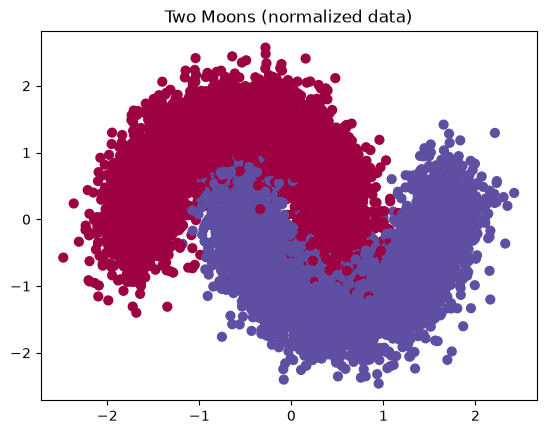

In [2]:
X, y = make_moons(n_samples=10000, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

plt.figure()
plt.scatter(X_train[:, 0].numpy(), X_train[:, 1].numpy(), s=40, c=y_train.numpy(), cmap=plt.cm.Spectral)
plt.title("Two Moons (normalized data)")
plt.show()

### MNIST Dataset  

The **MNIST dataset** is a large collection of handwritten digits (0–9), consisting of 60,000 training images and 10,000 test images.  
Each sample is a grayscale image of size $28 \times 28$, labeled with the corresponding digit.  
It is widely used as a benchmark for testing and comparing machine learning and deep learning algorithms.  

👉 You can find the dataset and details here: [MNIST Database](http://yann.lecun.com/exdb/mnist/)  


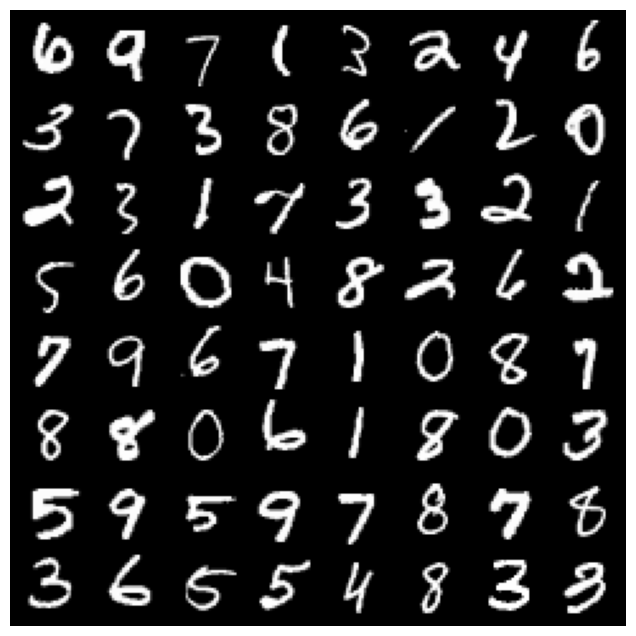

In [3]:
# Taken from https://github.com/pytorch/examples/blob/main/mnist/main.py#L116
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
mnist_train = datasets.MNIST(root="../../data", train=True, download=True, transform=transform)

loader = DataLoader(mnist_train, batch_size=64, shuffle=True)
images, labels = next(iter(loader))
grid = utils.make_grid(images, nrow=8, padding=2, normalize=True)
plt.figure(figsize=(8,8))
plt.imshow(grid.permute(1, 2, 0))  # convert CHW → HWC
plt.axis("off")
plt.show()

In [4]:
# We will treat each image like a flattened vector  
images[0][0].shape,  images[0][0].flatten().shape

(torch.Size([28, 28]), torch.Size([784]))

In [5]:
criterion = nn.CrossEntropyLoss()

In [6]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )
        
    def forward(self, x):
        return self.layers(x)

class DeepMLP(nn.Module):
    def __init__(self):
        super(DeepMLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 10)
        )
        
    def forward(self, x):
        x = x.view(-1, 28*28)
        return self.layers(x)

In [7]:
## Example of Batch GD

model = MLP()
optimizer = optim.SGD(model.parameters(), lr=0.1)
loss_hist_batch = []
epochs = 200
for epoch in tqdm(range(epochs)):
    # Forward pass on full dataset
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_hist_batch.append(loss.item())

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:57<00:00,  3.48it/s]


> **EXPERIMENT**: Does Batch Gradient Descent continue to decrease the loss indefinitely? Conduct an experiment to observe the behavior, and explain the results in alignment with the theoretical guarantees of gradient descent.

In [ ]:
## Example of Stochastic GD
model = MLP()
optimizer = optim.SGD(model.parameters(), lr=0.1)
loss_hist_stochastic = []
epochs = 200
n_samples = X_train.shape[0]

for epoch in tqdm(range(epochs)):
    # Shuffle indices each epoch
    indices = torch.randperm(n_samples)
    epoch_loss = 0.0
    
    for i in indices:
        Xi = X_train[i].unsqueeze(0)   # shape (1, features)
        yi = y_train[i].unsqueeze(0)   # shape (1,)
        
        outputs = model(Xi)
        loss = criterion(outputs, yi)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    # Average epoch loss
    loss_hist_stochastic.append(epoch_loss / n_samples)


 33%|██████████████████████████████████████████████████████▍                                                                                                              | 66/200 [04:24<05:14,  2.35s/it]

In [ ]:
## Example of Mini-Batch GD
batch_size = 32
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)

model = MLP()
optimizer = optim.SGD(model.parameters(), lr=0.1)
loss_hist_minibatch = []
epochs = 200

for epoch in tqdm(range(epochs)):
    epoch_loss = 0.0
    
    for Xi, yi in train_loader:
        outputs = model(Xi)
        loss = criterion(outputs, yi)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * Xi.shape[0]
    
    # Average epoch loss
    loss_hist_minibatch.append(epoch_loss / X_train.shape[0])

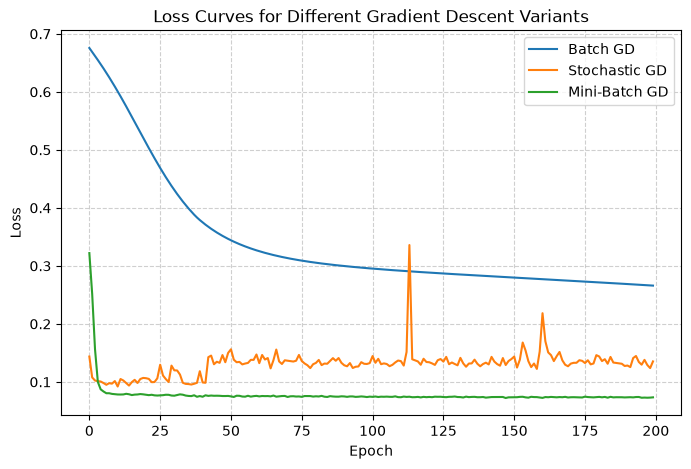

In [38]:
plt.figure(figsize=(8,5))
plt.plot(loss_hist_batch, label="Batch GD")
plt.plot(loss_hist_stochastic, label="Stochastic GD")
plt.plot(loss_hist_minibatch, label="Mini-Batch GD")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves for Different Gradient Descent Variants")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


In [ ]:
def train_two_moons(
    optimizer,
    optimizer_params,
    batch_size=32,
    n_epoch=200,
    log_grad_every=10,
    device="cpu"
):
    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    
    model = MLP().to(device)
    optimizer = optimizer(model.parameters(), **optimizer_params)
    
    loss_hist = []
    grad_logs = []
    step = 0
    
    for epoch in tqdm(range(n_epoch)):
        epoch_loss = 0.0
        
        for Xi, yi in train_loader:
            outputs = model(Xi.to(device))
            loss = criterion(outputs, yi.to(device))
            
            optimizer.zero_grad()
            loss.backward()

            # Log gradients every K steps
            if step % log_grad_every == 0:
                grads = []
                for p in model.parameters():
                    if p.grad is not None:
                        grads.append(p.grad.detach().view(-1).abs().cpu())
                grad_logs.append(torch.cat(grads))  # 1D tensor of |grad|
            
            optimizer.step()
            
            epoch_loss += loss.item() * Xi.shape[0]
        
        # Average epoch loss
        loss_hist.append(epoch_loss / X_train.shape[0])

    return loss_hist, grad_logs

def train_MNIST(
    optimizer,
    optimizer_params,
    batch_size=64,
    n_epoch=30,
    log_grad_every=10,
    device="cuda"
):
    train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True)
    
    model = DeepMLP().to(device)
    optimizer = optimizer(model.parameters(), **optimizer_params)
    
    loss_hist = []
    grad_logs = []
    step = 0
    
    for epoch in tqdm(range(n_epoch)):
        epoch_loss = 0.0
        
        for Xi, yi in train_loader:
            outputs = model(Xi.to(device))
            loss = criterion(outputs, yi.to(device))
            
            optimizer.zero_grad()
            loss.backward()

            # Log gradients every K steps
            if step % log_grad_every == 0:
                grads = []
                for p in model.parameters():
                    if p.grad is not None:
                        grads.append(p.grad.detach().view(-1).abs().cpu())
                grad_logs.append(torch.cat(grads))  # 1D tensor of |grad|
            
            optimizer.step()
            
            epoch_loss += loss.item() * Xi.shape[0]
        
        # Average epoch loss
        loss_hist.append(epoch_loss / X_train.shape[0])

    return loss_hist, grad_logs

def plot_gradient_hist_grid(
    grad_logs,
    bins=50,
    max_plots=9,
    title="Gradient Distributions Over Time",
):
    """
    Plot gradient histograms at evenly spaced training snapshots.

    grad_logs: list of tensors
    bins: number of histogram bins
    max_plots: maximum number of snapshots to show
    title: figure title
    """
    n_plots = min(max_plots, len(grad_logs))

    snapshots = np.linspace(
        0,
        len(grad_logs) - 1,
        n_plots,
        dtype=int,
    )

    ncols = int(np.ceil(np.sqrt(n_plots)))
    nrows = int(np.ceil(n_plots / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(15, 10),
        sharex=True,
        sharey=True,
    )

    axes = np.atleast_1d(axes).flatten()

    # Collect selected gradients first so all plots use identical bins
    selected_grads = []

    for idx in snapshots:
        grads = (
            grad_logs[idx]
            .detach()
            .cpu()
            .flatten()
            .to(torch.float64)
            .numpy()
        )

        grads = grads[np.isfinite(grads)]
        selected_grads.append(grads)

    # Determine one global range for all histograms
    non_empty = [g for g in selected_grads if g.size > 0]

    if not non_empty:
        raise ValueError("No finite gradient values found.")

    global_min = min(g.min() for g in non_empty)
    global_max = max(g.max() for g in non_empty)

    # Handle degenerate case where every gradient is identical
    if global_min == global_max:
        eps = max(abs(global_min) * 1e-6, 1e-12)
        global_min -= eps
        global_max += eps

    bin_edges = np.linspace(
        global_min,
        global_max,
        bins + 1,
        dtype=np.float64,
    )

    # Slightly move the last boundary outward to avoid NumPy
    # floating-point bin-indexing edge cases
    bin_edges[-1] = np.nextafter(bin_edges[-1], np.inf)

    for i, (idx, grads) in enumerate(zip(snapshots, selected_grads)):
        if grads.size == 0:
            axes[i].set_title(f"Step {idx} (empty)")
            continue

        # Explicitly keep values inside histogram range
        grads = np.clip(
            grads,
            bin_edges[0],
            np.nextafter(bin_edges[-1], -np.inf),
        )

        # Compute histogram ourselves rather than relying on
        # matplotlib to infer/recompute bin edges.
        counts, edges = np.histogram(
            grads,
            bins=bin_edges,
        )

        widths = np.diff(edges)

        axes[i].bar(
            edges[:-1],
            counts,
            width=widths,
            align="edge",
            alpha=0.7,
        )

        axes[i].set_yscale("log")
        axes[i].set_title(f"Step {idx}")

    # Hide unused axes
    for j in range(n_plots, len(axes)):
        axes[j].axis("off")

    fig.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

<a id='SGD_Modifications'></a>
# SGD Modifications

## Momentum

<img src="images/sgd_with_momentum.jpg" alt="SGD with momentum meme" width="300"/>

If the cost surface is not spherical, learning can be slow because the learning rate must be kept small to prevent divergence along steep curvature directions.  
The **SGD with momentum** (applicable to both full-batch or mini-batch learning) attempts to use the previous step to speed up learning, especially along dimensions where the gradient consistently points in the same direction.  

The main idea of the momentum method:  
- Speed up learning along directions where gradients keep the same sign.  
- Slow down oscillations along directions where gradients frequently change sign.  

Formally, the update method has the following form from iteration $t-1$ to $t$:

$$
\Delta x_t = \rho \Delta x_{t-1} - \eta \frac{\partial L(x_t)}{\partial x_t},
$$

where the algorithm remembers the last update and adds it to the current update using a parameter $\rho$, called the **momentum parameter**.  

- The parameter $\rho$ blends the present update with the past update.  
- The amount of parameter change is proportional to the negative gradient plus the previous weight change.  
- The added **momentum term** acts as both a smoother and an accelerator.  

The parameter $\rho$ works as a **decay constant**:  
- Its effect decays exponentially over time.  
- In practice, $\rho$ is usually set to $0.9$.  

Momentum simulates the concept of inertia in physics:  
- Each update includes not only the current gradient (dynamic term)  
- but also a fraction of the previous update (momentum term).

![Image Title](images/momentum.png)
*Taken from [Gradient Descent, Stochastic Optimization, and Other Tales](https://arxiv.org/pdf/2205.00832)*


In [ ]:
## Example of Mini-Batch GD

two_moons_sgd, two_moons_sgd_grads = train_two_moons(
    optimizer=torch.optim.SGD,
    optimizer_params=dict(lr=0.1)
)
MNIST_sgd, MNIST_sgd_grads = train_MNIST(
    optimizer=torch.optim.SGD,
    optimizer_params=dict(lr=0.01)
)

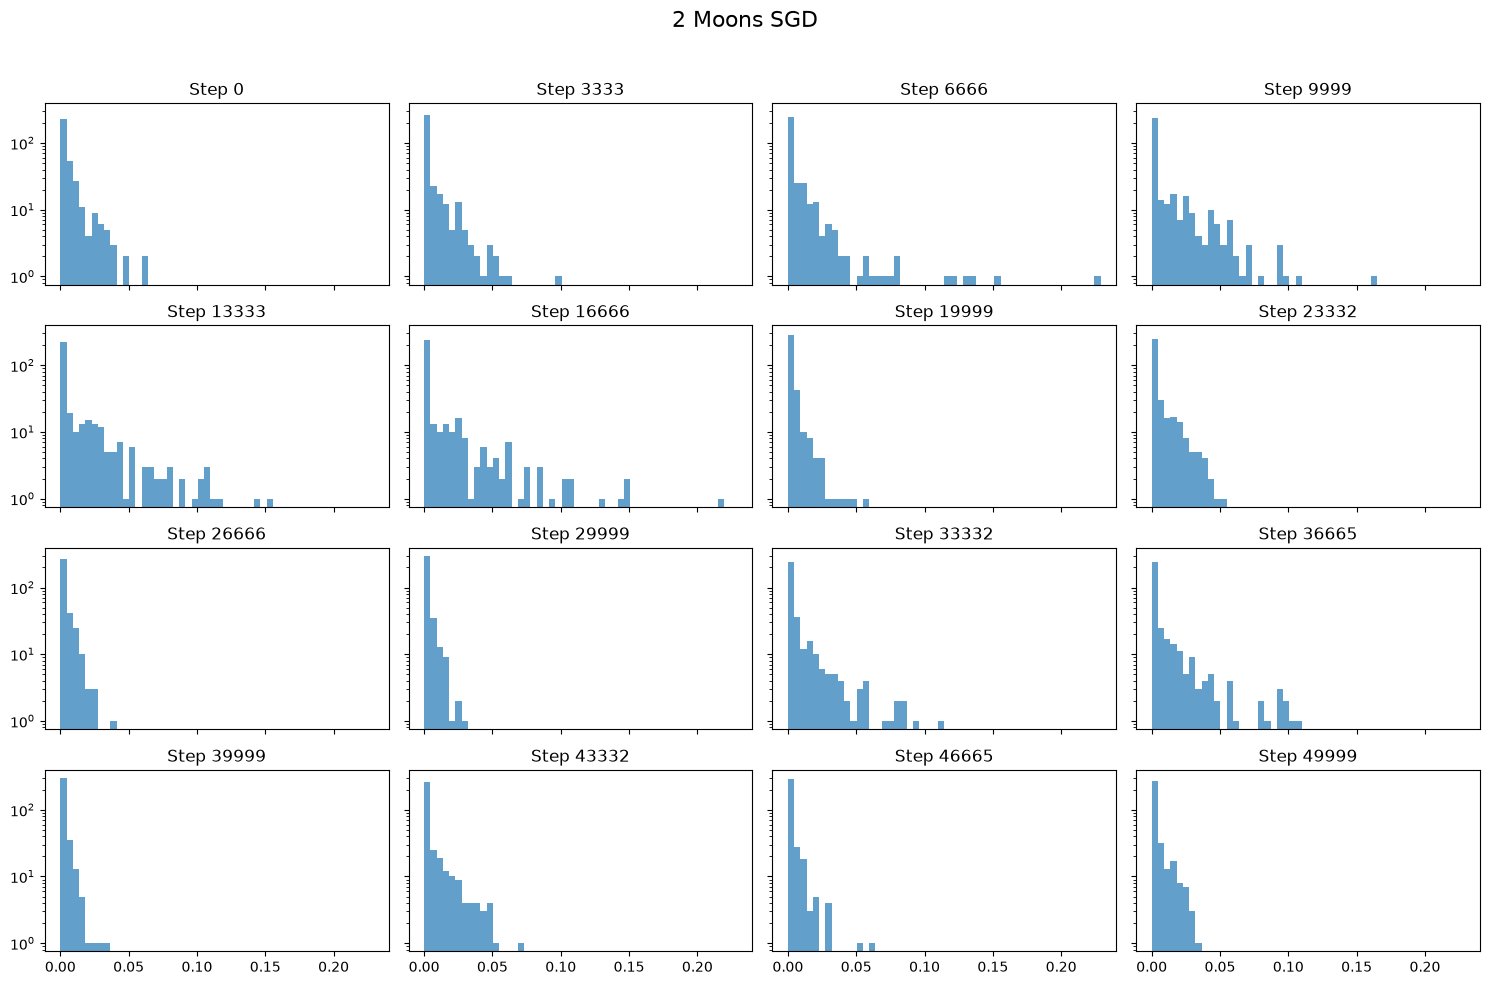

In [39]:
plot_gradient_hist_grid(two_moons_sgd_grads, max_plots=16, title="2 Moons SGD")

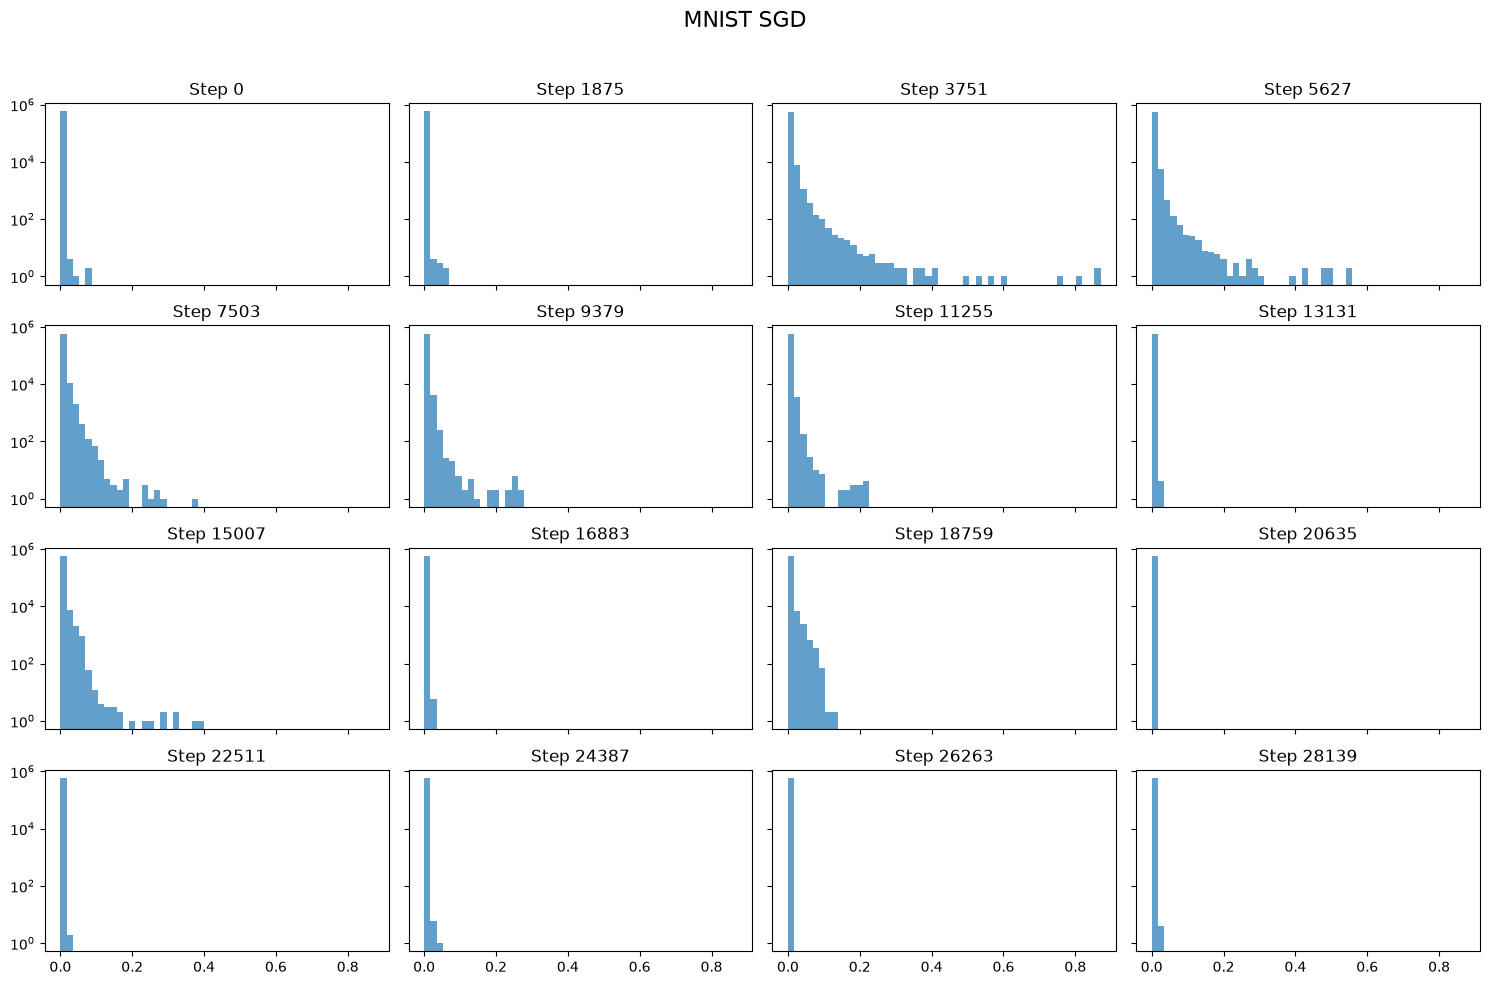

In [40]:
plot_gradient_hist_grid(MNIST_sgd_grads, max_plots=16, title="MNIST SGD")

In [58]:
del two_moons_sgd_grads, MNIST_sgd_grads
gc.collect()

1243846

In [ ]:
## Example of Mini-Batch GD with momentum

two_moons_sgd_momentum, two_moons_sgd_momentum_grads = train_two_moons(
    optimizer=torch.optim.SGD,
    optimizer_params=dict(lr=0.1, momentum=0.9)
)
MNIST_sgd_momentum, MNIST_sgd_momentum_grads = train_MNIST(
    optimizer=torch.optim.SGD,
    optimizer_params=dict(lr=0.01, momentum=0.9)
)

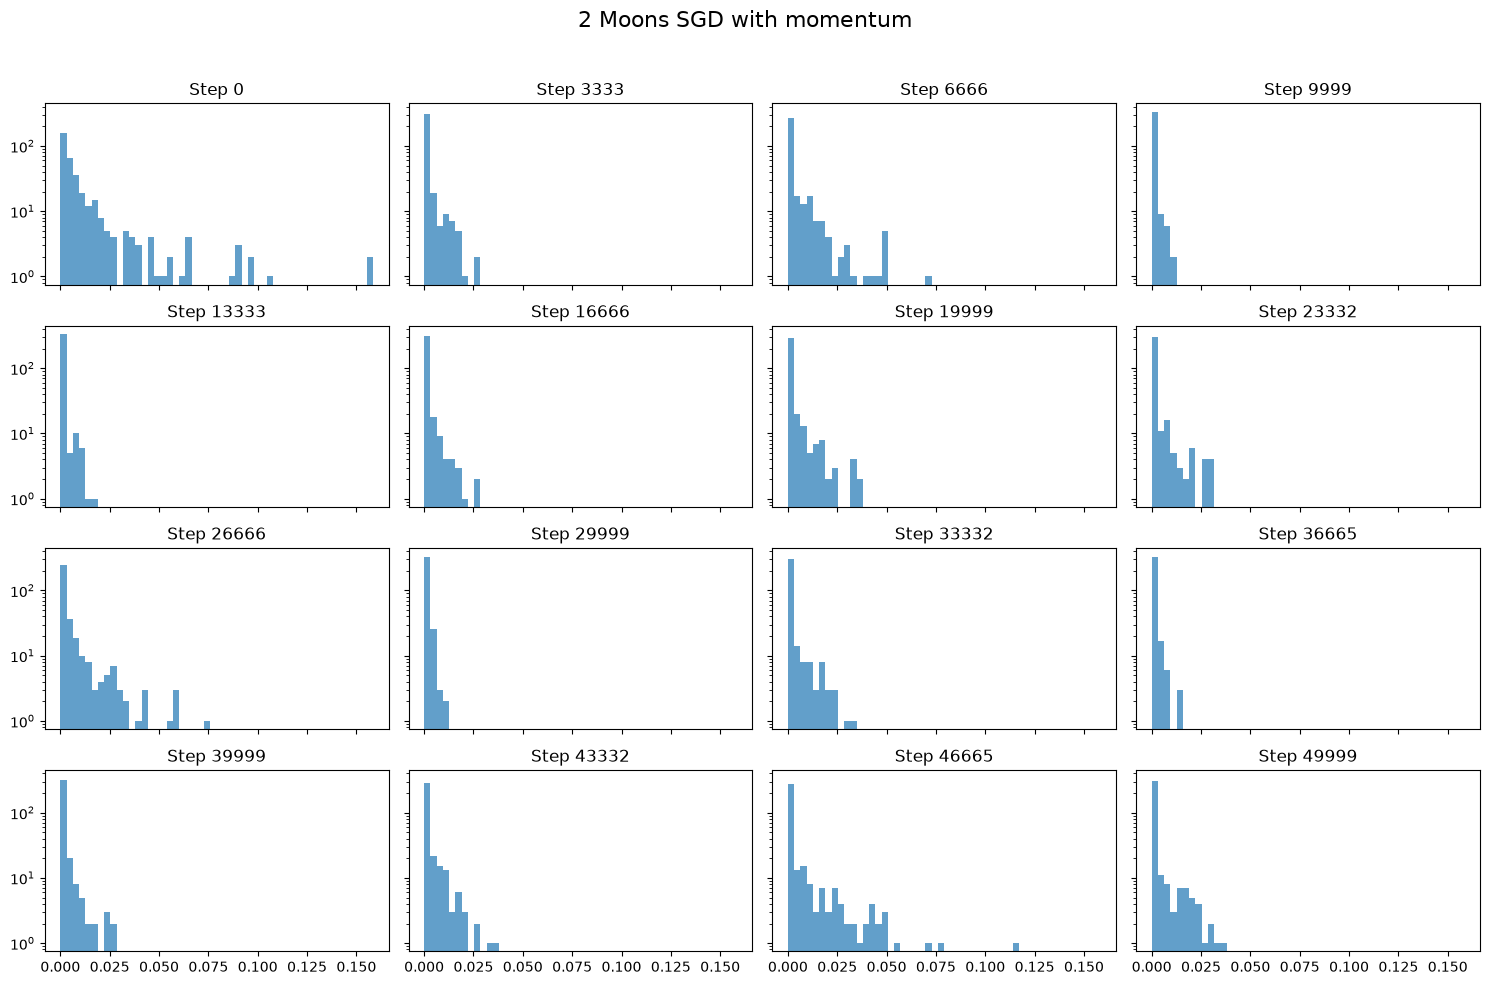

In [41]:
plot_gradient_hist_grid(two_moons_sgd_momentum_grads, max_plots=16, title="2 Moons SGD with momentum")

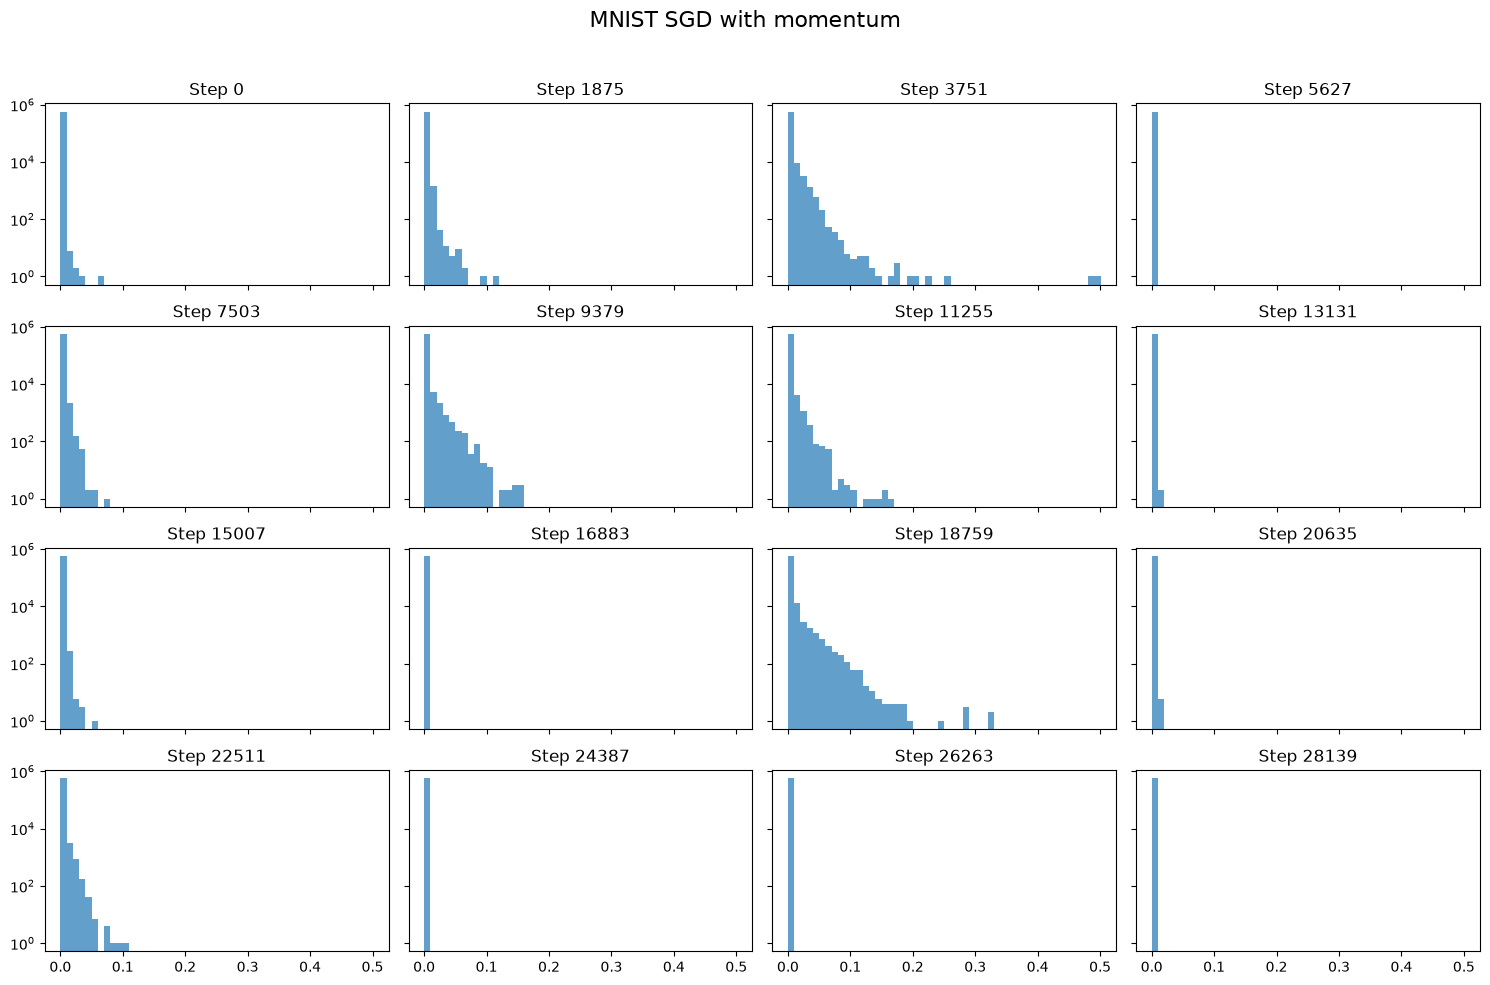

In [42]:
plot_gradient_hist_grid(MNIST_sgd_momentum_grads, max_plots=16, title="MNIST SGD with momentum")

In [59]:
del two_moons_sgd_momentum_grads, MNIST_sgd_momentum_grads
gc.collect()

138392

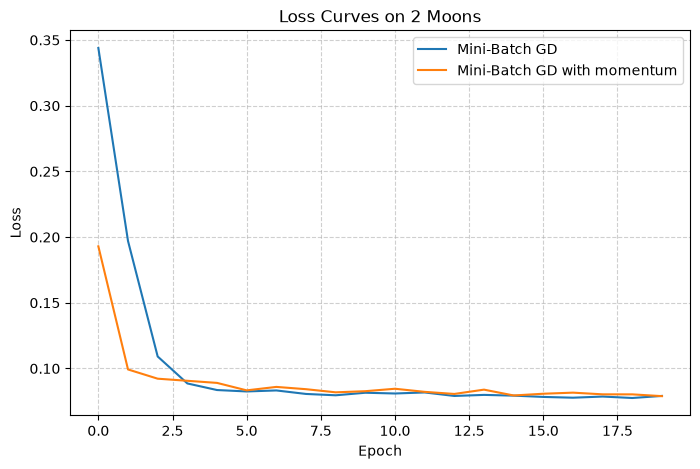

In [43]:
plt.figure(figsize=(8,5))
plt.plot(two_moons_sgd[:20], label="Mini-Batch GD")
plt.plot(two_moons_sgd_momentum[:20], label="Mini-Batch GD with momentum")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves on 2 Moons")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

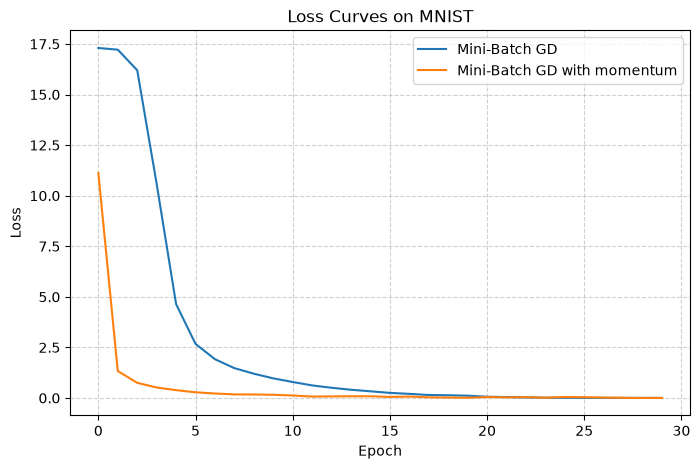

In [44]:
plt.figure(figsize=(8,5))
plt.plot(MNIST_sgd, label="Mini-Batch GD")
plt.plot(MNIST_sgd_momentum, label="Mini-Batch GD with momentum")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves on MNIST")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## Nesterov Momentum

Nesterov momentum, also known as **Nesterov Accelerated Gradient (NAG)**, is a slightly different version of the momentum update that has recently gained popularity.

The core idea is:  
- At position $x_t$, the momentum term alone (ignoring the gradient) will nudge the parameter vector by $\rho \Delta x_{t-1}$.  
- Instead of computing the gradient at the old position $x_t$, we look **ahead** to the approximate future position $x_t + \rho \Delta x_{t-1}$.  
- This lookahead makes the method more accurate and responsive to changes in the gradient direction.

Thus, it makes sense to compute the gradient at $x_t + \rho \Delta x_{t-1}$ rather than $x_t$.  

The update step becomes:

$$
\Delta x_t = \rho \Delta x_{t-1} - \eta \frac{\partial L(x_t + \rho \Delta x_{t-1})}{\partial x}
$$

![Image Title](images/nesterov_momentum.png)
*Taken from [Gradient Descent, Stochastic Optimization, and Other Tales](https://arxiv.org/pdf/2205.00832)*


In [ ]:
## Example of Mini-Batch GD with Nesterov momentum

two_moons_sgd_momentum_nesterov, two_moons_sgd_momentum_nesterov_grad = train_two_moons(
    optimizer=torch.optim.SGD,
    optimizer_params=dict(lr=0.1, momentum=0.9, nesterov=True)
)
MNIST_sgd_momentum_nesterov, MNIST_sgd_momentum_nesterov_grad = train_MNIST(
    optimizer=torch.optim.SGD,
    optimizer_params=dict(lr=0.01, momentum=0.9, nesterov=True)
)

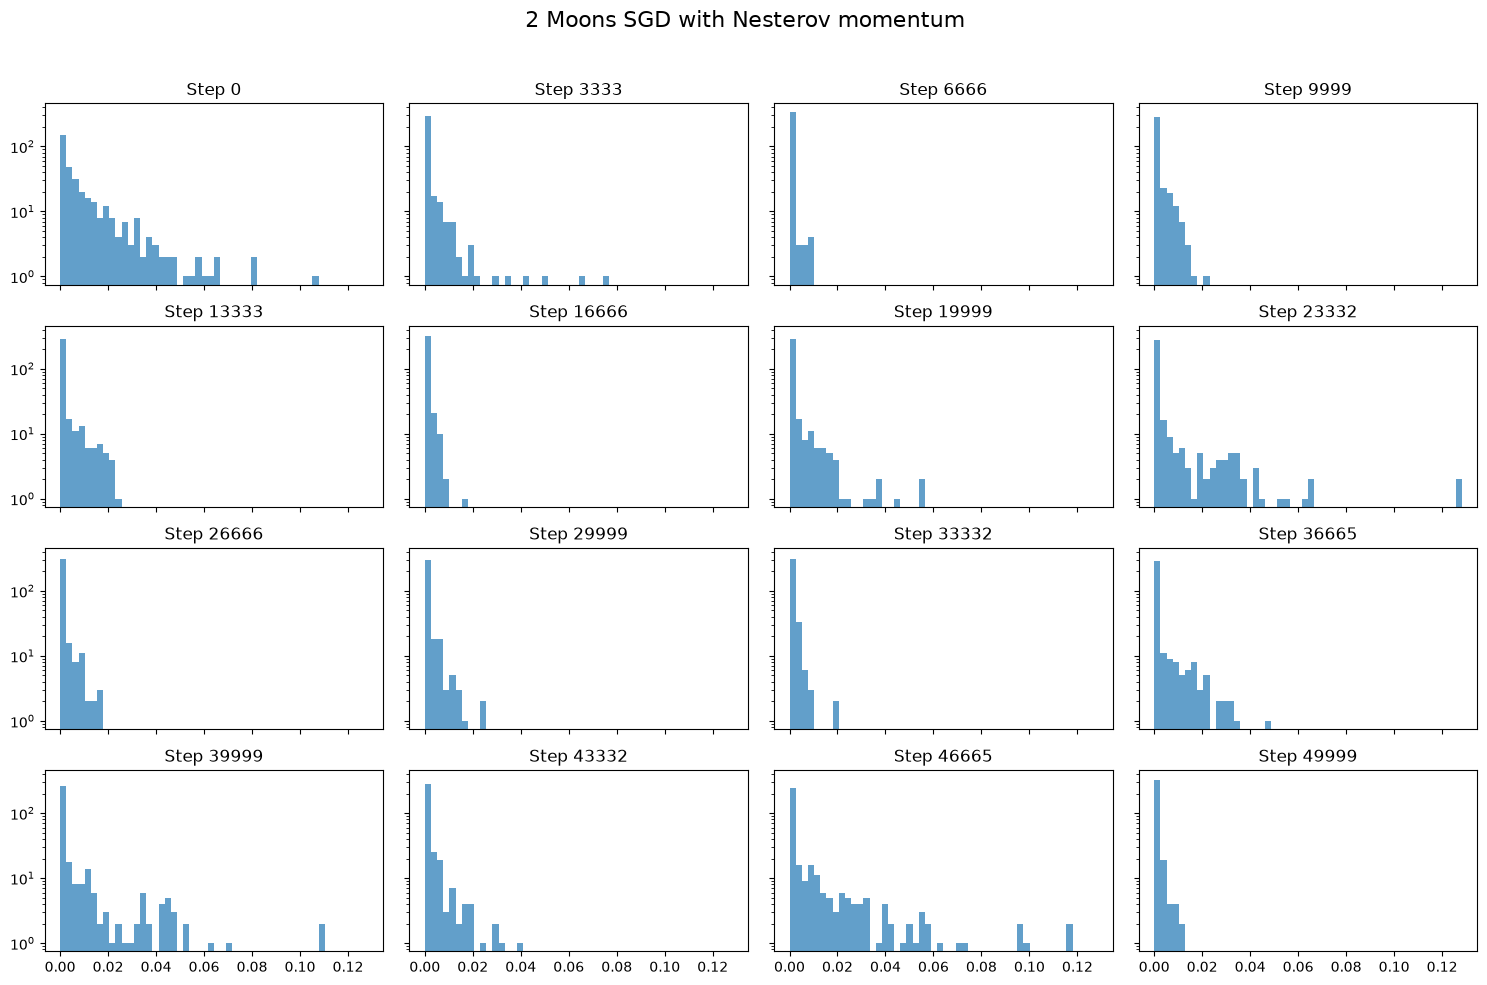

In [45]:
plot_gradient_hist_grid(two_moons_sgd_momentum_nesterov_grad, max_plots=16, title="2 Moons SGD with Nesterov momentum")

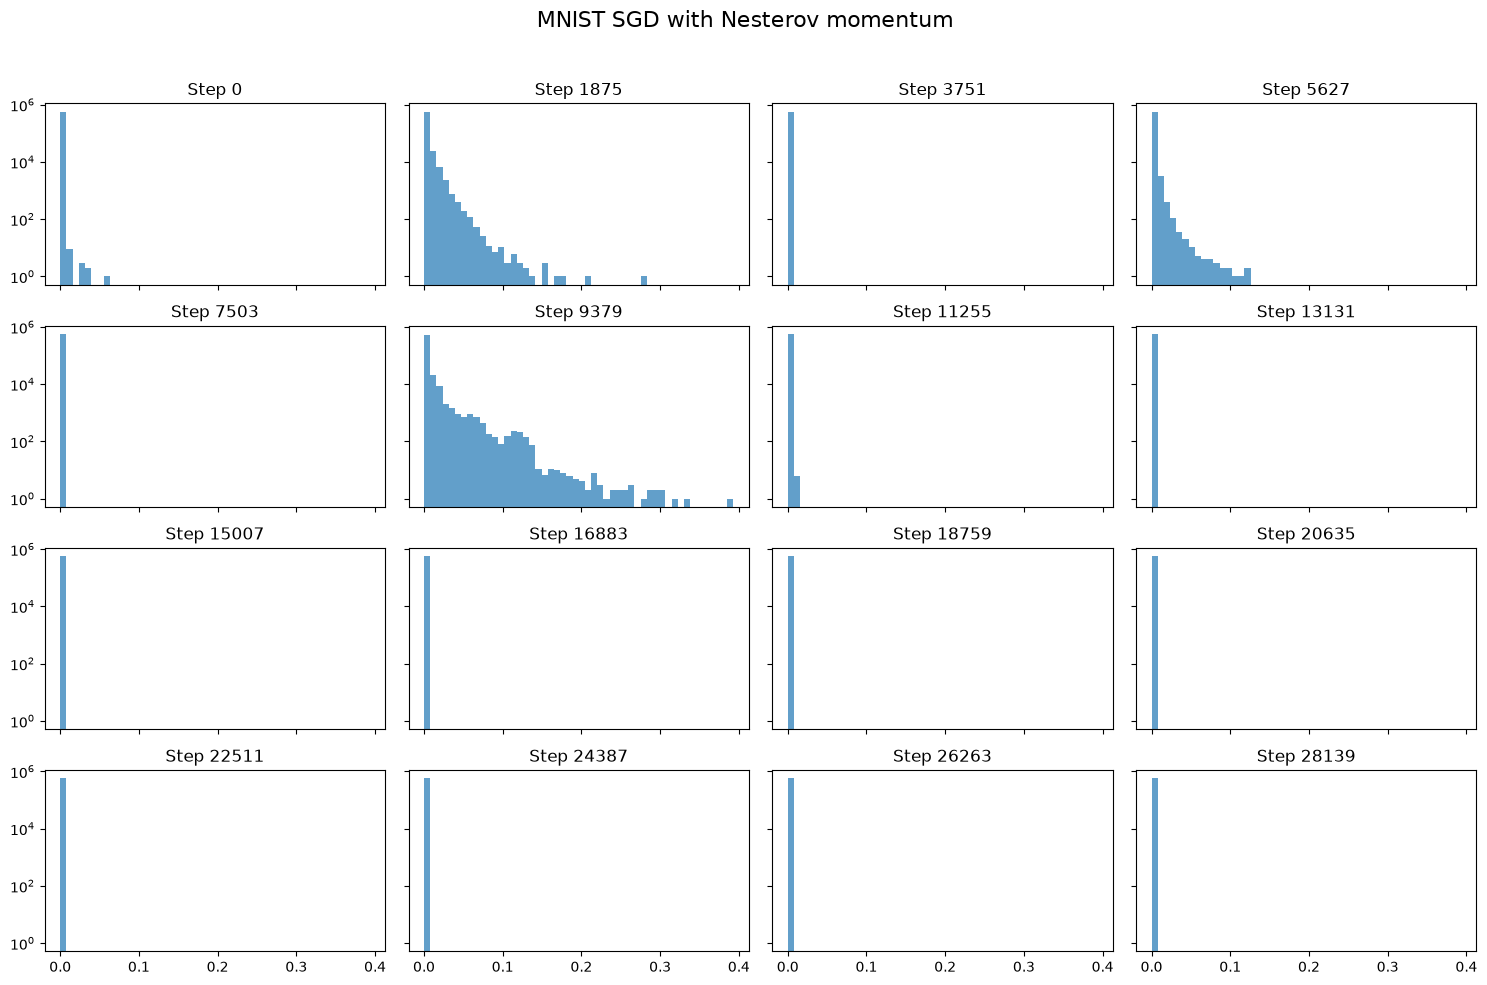

In [46]:
plot_gradient_hist_grid(MNIST_sgd_momentum_nesterov_grad, max_plots=16, title="MNIST SGD with Nesterov momentum")

In [60]:
del two_moons_sgd_momentum_nesterov_grad, MNIST_sgd_momentum_nesterov_grad
gc.collect()

0

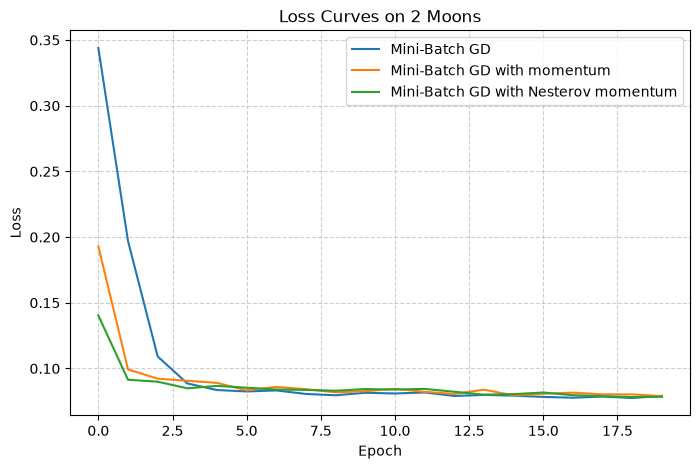

In [47]:
plt.figure(figsize=(8,5))
plt.plot(two_moons_sgd[:20], label="Mini-Batch GD")
plt.plot(two_moons_sgd_momentum[:20], label="Mini-Batch GD with momentum")
plt.plot(two_moons_sgd_momentum_nesterov[:20], label="Mini-Batch GD with Nesterov momentum")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves on 2 Moons")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

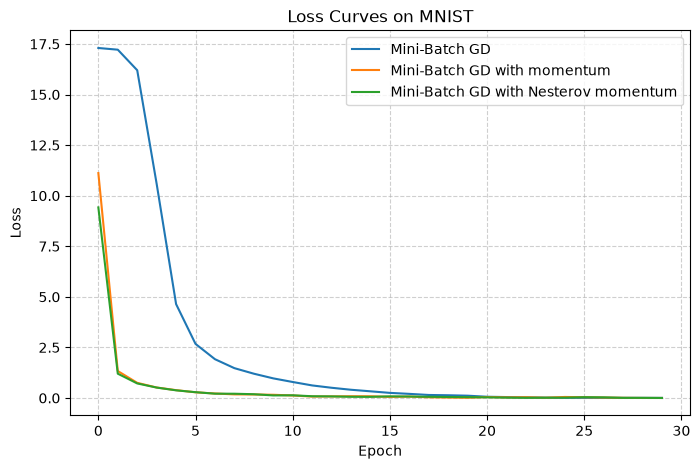

In [48]:
plt.figure(figsize=(8,5))
plt.plot(MNIST_sgd, label="Mini-Batch GD")
plt.plot(MNIST_sgd_momentum, label="Mini-Batch GD with momentum")
plt.plot(MNIST_sgd_momentum_nesterov, label="Mini-Batch GD with Nesterov momentum")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves on MNIST")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

<a id='RMSProp'></a>
# RMSProp

## AdaGrad

The learning rate annealing procedure modifies a single global learning rate that is applied to all dimensions of the parameters.  
Duchi et al. (2011) proposed **AdaGrad**, where the learning rate is updated on a per-dimension basis.  

- The learning rate for each parameter depends on the history of gradient updates of that parameter.  
- Parameters with a scarce history of updates can be updated faster (larger learning rate).  
- Parameters that have already been updated many times receive smaller learning rates.  

Formally, the AdaGrad update step is:

$$
\Delta x_t = - \frac{\eta}{\sqrt{\sum_{i=1}^t g_i^2 + \epsilon}} \odot g_t
$$

where:  
- $\eta$ is the global learning rate (shared by all dimensions).  
- $g_t$ is the gradient at step $t$.  
- $g_i^2$ is the element-wise squared gradient.  
- $\odot$ denotes element-wise multiplication.  
- $\epsilon$ is a small smoothing term for numerical stability.  

### Advantages
- Adapts learning rates individually for each parameter dimension.  
- Larger gradients → smaller learning rate; smaller gradients → larger learning rate.  
- Naturally reduces the need to manually tune learning rates.  
- Simple and efficient to implement.  

### Drawbacks
- **Unbounded accumulation of squared gradients**:  
  The denominator keeps growing, so learning rates shrink over time and can become infinitesimally small, effectively stopping training.  
- **Sensitive to parameter initialization and gradient magnitudes**:  
  Large initial gradients → tiny learning rates; small initial gradients → inefficient updates.  
- Ignores the **sign** of gradients (only squared values matter).  
- Still requires a manually chosen global learning rate $ \eta $.



## RMSProp

RMSProp is an extension of AdaGrad designed to overcome its main weakness:  
the **unbounded accumulation of squared gradients** in the denominator, which causes learning rates to decay to zero.  

Instead of accumulating all squared gradients from the beginning, RMSProp uses an **exponentially decaying average** of past squared gradients.  
This is similar in spirit to the momentum method (with a decay constant $\rho$).  

---

### Formulation

At time $t$, the running average of squared gradients is:

$ E[g^2]_t = \rho E[g^2]_{t-1} + (1-\rho) g_t^2 $  

where:  
- $g_t$ is the gradient at time $t$.  
- $\rho$ is the decay constant (typically $\rho \in [0.5, 0.9]$).  

The root mean squared (RMS) error criterion is then:

$ \text{RMS}[g]_t = \sqrt{E[g^2]_t + \epsilon} $  

with $\epsilon$ added for numerical stability.  

The RMSProp update rule is:

$ \Delta x_t = - \frac{\eta}{\text{RMS}[g]_t} \odot g_t $  


### Important Note on Initialization Bias

- The running estimate $E[g^2]_t$ is initialized to 0 at the start of training.  
- This **introduces a bias** in the early iterations, since the average starts lower than it should.  
- However, the bias **disappears over the long term** as more gradients are accumulated.  
- Additionally, old gradients decay exponentially, so their influence gradually vanishes.

### Exponential Moving Average and Window Interpretation

$SC$ is a smoothing constant 

$ SC = 1 - \rho \approx \frac{2}{N+1}, $

where $N$ can be interpreted as the **effective window size** of past gradients.  

- If $\rho = 0.9$, then $SC = 0.1 \approx \frac{2}{20}$, corresponding to a window of about $N = 19$.  
- This means $E[g^2]_t$ is approximately the moving average of the past 19 squared gradients and the current one (a total of ~20).  
- Smaller $\rho$ → smaller window (shorter memory, more weight on recent gradients).  
- Larger $\rho$ → larger window (longer memory, smoother estimate).  

Thus, $\rho$ controls how much history RMSProp remembers:  
- $\rho = 0.5$ corresponds to a short window (reacts quickly to new gradients).  
- $\rho = 0.9$ corresponds to a longer window (smooths fluctuations).  
- As $\rho \to 1$, the window size $N \to \infty$, meaning the method approaches AdaGrad.  


---

### Interpretation
- RMSProp **rescales the gradient** by a moving average of its recent magnitudes.  
- This prevents the learning rate from shrinking indefinitely (as in AdaGrad).  
- The effect is that parameters with consistently large gradients get smaller updates, while parameters with smaller gradients get relatively larger updates.  

---

### Advantages
- Fixes AdaGrad’s main weakness by using an exponentially decaying average instead of summing all squared gradients.  
- Suitable for **non-convex problems**, such as training deep neural networks.  
- Automatically adjusts learning rates per parameter dimension.  
- Easy to implement and widely used in practice.  

---

### Drawbacks
- The learning rate $\eta$ still needs to be set manually.  
- Sensitive to the choice of decay constant $\rho$ (common default is $0.9$).  
- Considers only the **magnitude** of gradients, not their sign.  
- May still cause small learning rates near sharp or local minima.

**Main Application: [Recurrent Neural Nets](https://arxiv.org/pdf/1308.0850v5)**

In [ ]:
## Example of Mini-Batch with RMSProp

two_moons_rmsprop, two_moons_rmsprop_grad = train_two_moons(
    optimizer=torch.optim.RMSprop,
    optimizer_params=dict(lr=0.1, alpha=0.9)
)
MNIST_rmsprop, MNIST_rmsprop_grad = train_MNIST(
    optimizer=torch.optim.RMSprop,
    optimizer_params=dict(lr=0.001, alpha=0.9)
)

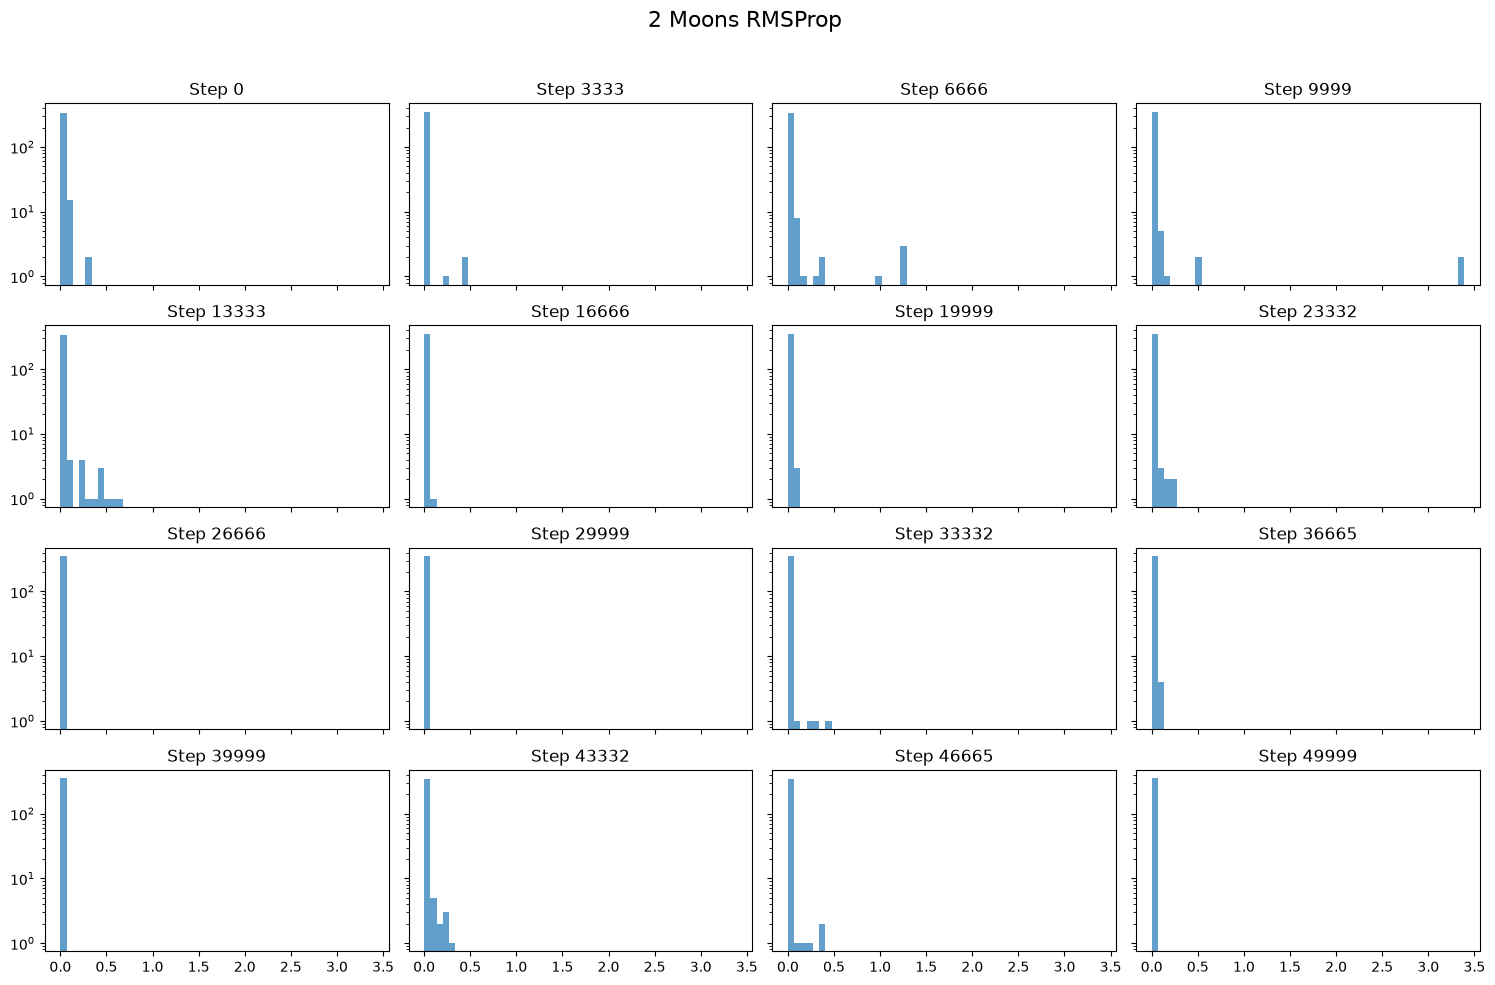

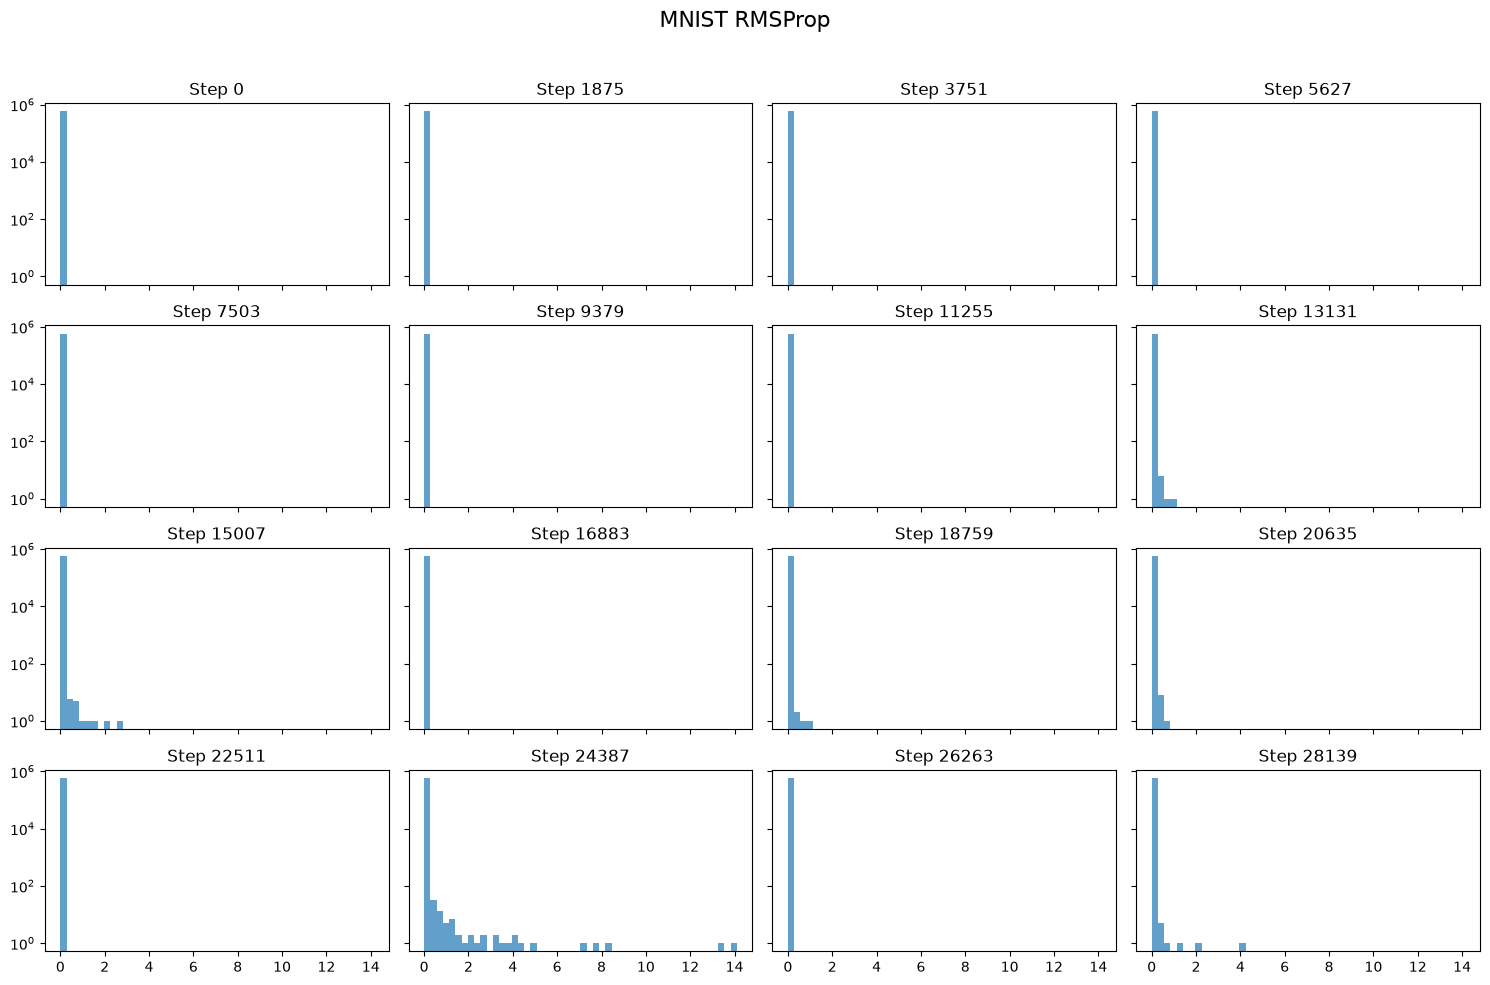

In [49]:
plot_gradient_hist_grid(two_moons_rmsprop_grad, max_plots=16, title="2 Moons RMSProp")
plot_gradient_hist_grid(MNIST_rmsprop_grad, max_plots=16, title="MNIST RMSProp")

In [61]:
del two_moons_rmsprop_grad, MNIST_rmsprop_grad
gc.collect()

0

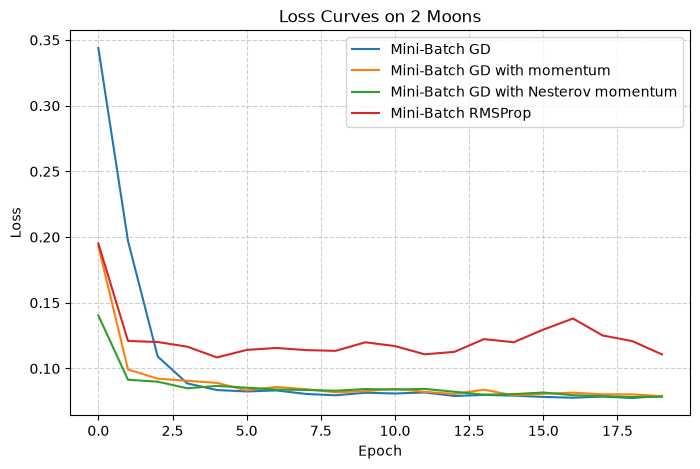

In [50]:
plt.figure(figsize=(8,5))
plt.plot(two_moons_sgd[:20], label="Mini-Batch GD")
plt.plot(two_moons_sgd_momentum[:20], label="Mini-Batch GD with momentum")
plt.plot(two_moons_sgd_momentum_nesterov[:20], label="Mini-Batch GD with Nesterov momentum")
plt.plot(two_moons_rmsprop[:20], label="Mini-Batch RMSProp")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves on 2 Moons")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

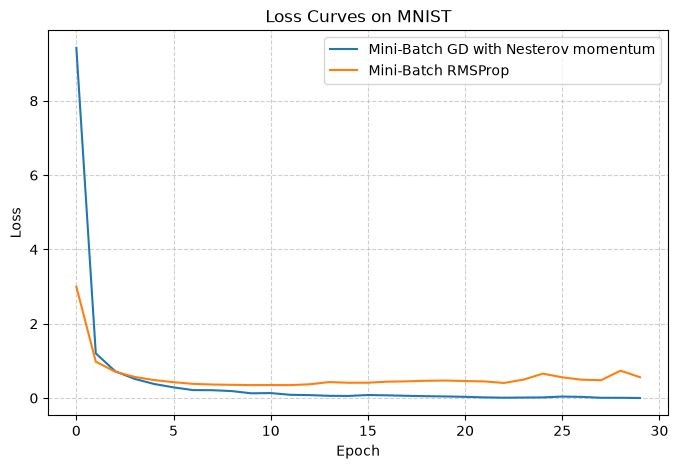

In [51]:
plt.figure(figsize=(8,5))
# plt.plot(MNIST_sgd, label="Mini-Batch GD")
# plt.plot(MNIST_sgd_momentum, label="Mini-Batch GD with momentum")
plt.plot(MNIST_sgd_momentum_nesterov, label="Mini-Batch GD with Nesterov momentum")
plt.plot(MNIST_rmsprop, label="Mini-Batch RMSProp")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves on MNIST")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

<a id='Adam'></a>
# Adam (Adaptive Moment Estimation)

**Adam** (Kingma and Ba, 2014) is another adaptive learning rate optimization algorithm.  
It combines ideas from **Momentum** (first-order information) and **RMSProp** (second-order scaling).  

- Adam keeps an exponentially decaying average of the **first moment** (mean of gradients).  
- It also keeps an exponentially decaying average of the **second moment** (uncentered variance of gradients).  

Formally:

$ m_t = \rho_1 m_{t-1} + (1-\rho_1) g_t $  
$ v_t = \rho_2 v_{t-1} + (1-\rho_2) g_t^2 $  

where:  
- $m_t$ is the first moment estimate (mean).  
- $v_t$ is the second moment estimate (variance).  
- $\rho_1, \rho_2$ are decay constants (defaults: $\rho_1 = 0.9$, $\rho_2 = 0.999$).  

---

### Bias Correction

Like RMSProp, these moving averages are initialized at 0, which introduces a bias towards zero in the early steps.  
Adam corrects this bias with:

$ \hat{m}_t = \frac{m_t}{1-\rho_1^t}, \quad \hat{v}_t = \frac{v_t}{1-\rho_2^t} $

---

### Update Rule

The parameter update step is:

$ \Delta x_t = - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \odot \hat{m}_t $  

and therefore:

$ x_{t+1} = x_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \odot \hat{m}_t $  

where $\eta$ is the learning rate and $\epsilon$ is a small smoothing term (default $10^{-8}$).  

---

### Practical Defaults

Kingma and Ba (2014) suggest:  
- $\rho_1 = 0.9$  
- $\rho_2 = 0.999$  
- $\epsilon = 10^{-8}$  

**Adam is a baseline solution (and in most cases the best solution) in most deep learning tasks**

In [ ]:
## Example of Mini-Batch with Adam

two_moons_adam, two_moons_adam_grad = train_two_moons(
    optimizer=torch.optim.Adam,
    optimizer_params=dict(lr=0.1, betas=(0.9, 0.999))
)
MNIST_adam, MNIST_adam_grad = train_MNIST(
    optimizer=torch.optim.Adam,
    optimizer_params=dict(lr=0.001, betas=(0.9, 0.999))
)

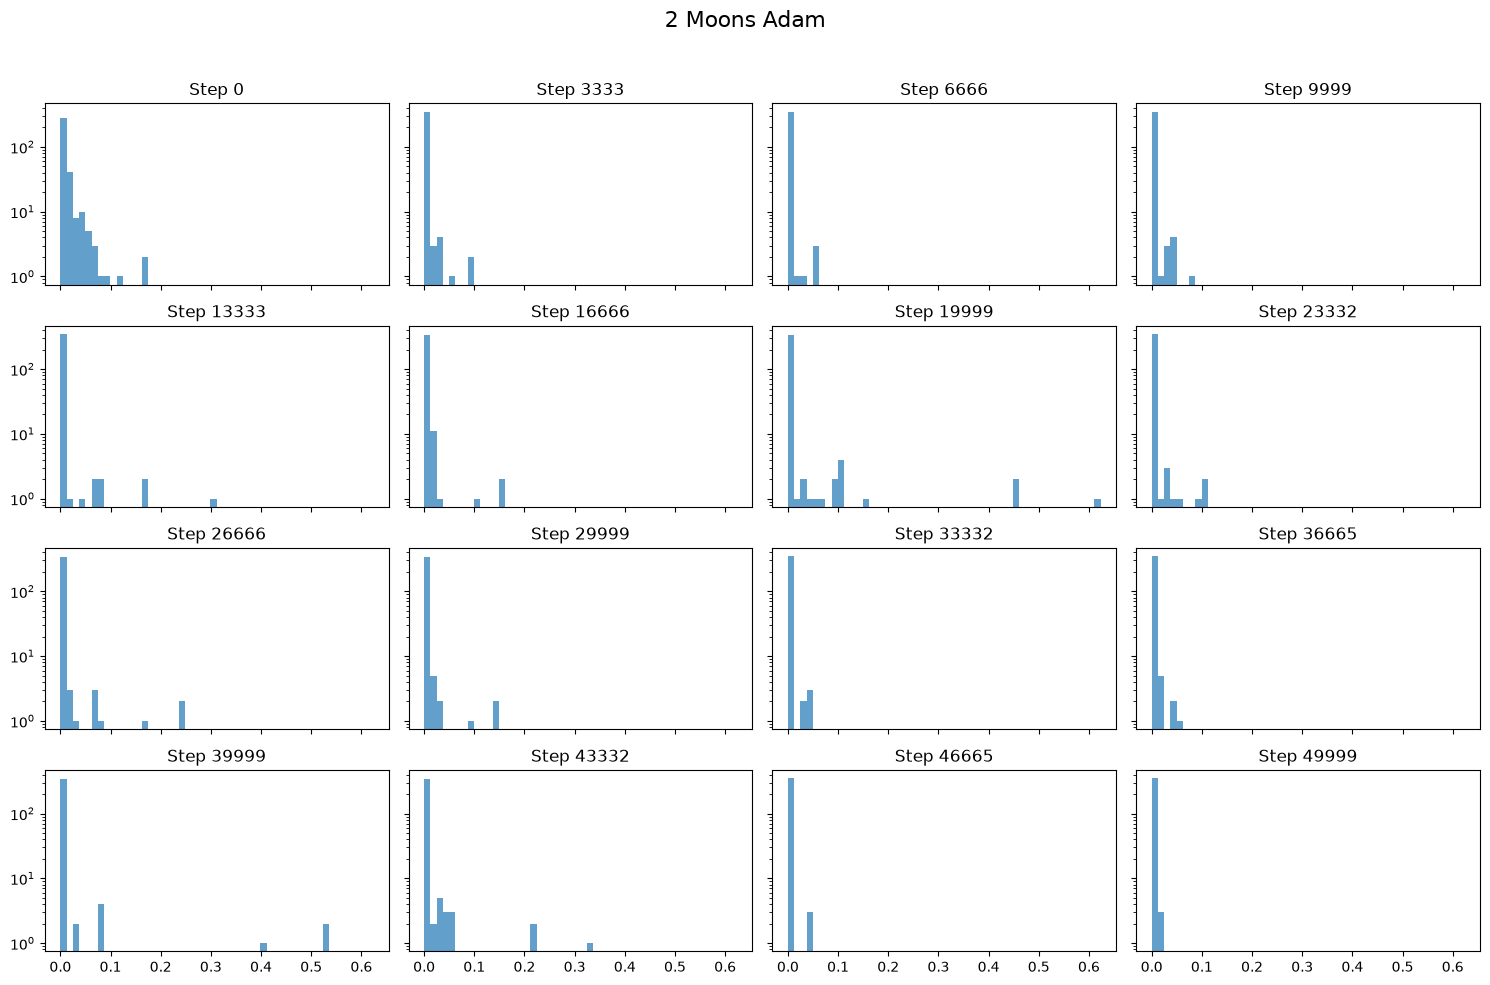

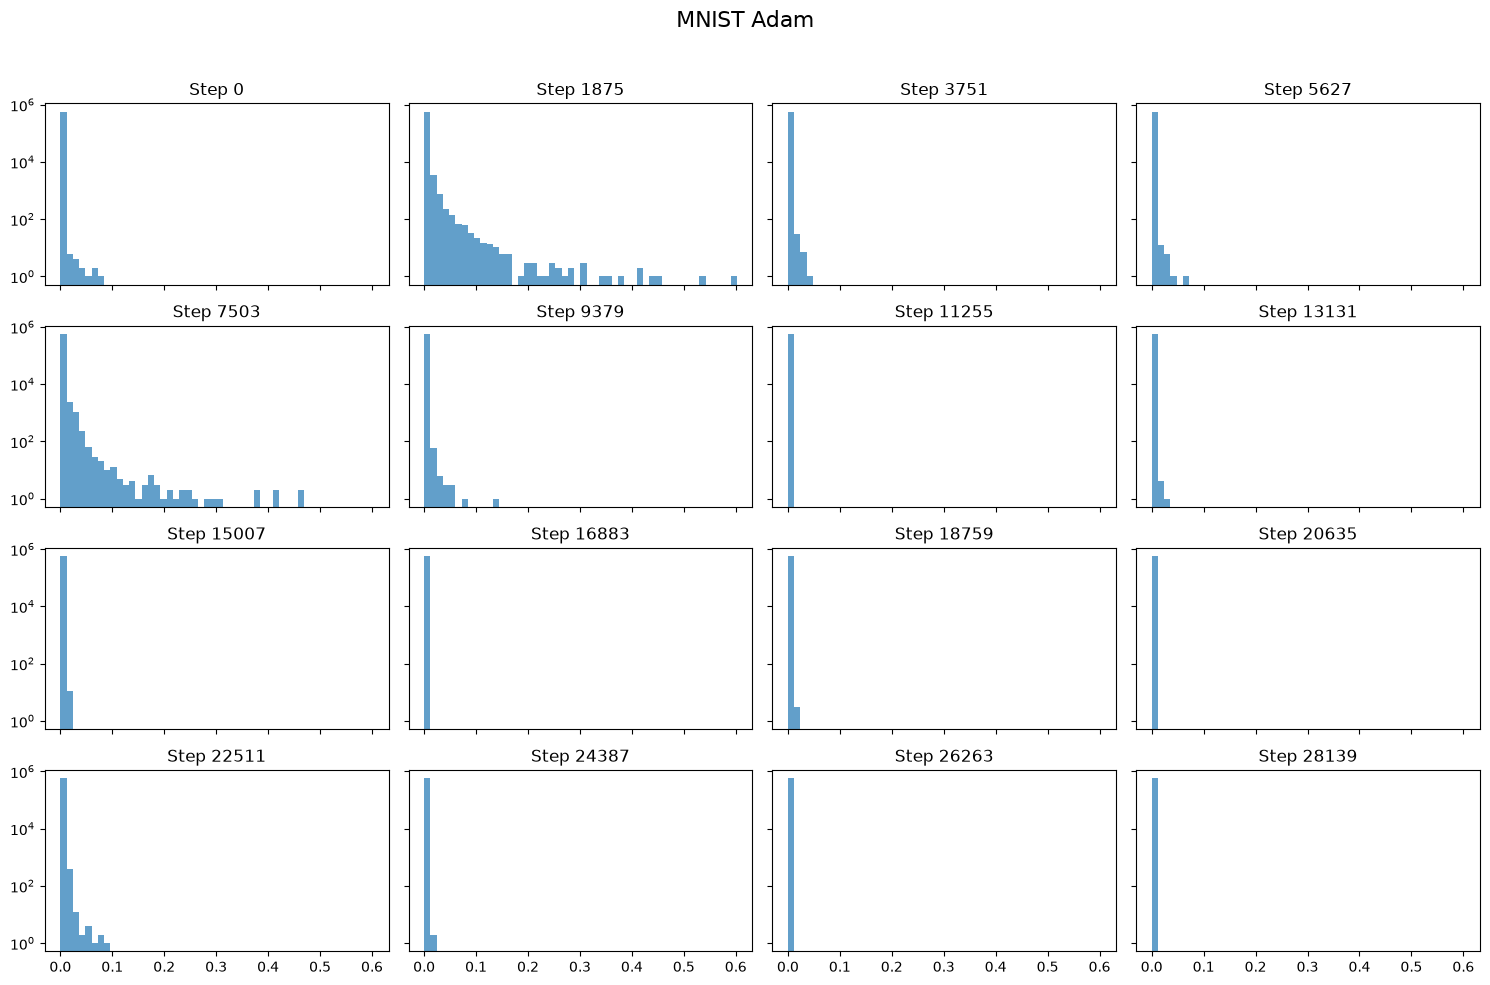

In [52]:
plot_gradient_hist_grid(two_moons_adam_grad, max_plots=16, title="2 Moons Adam")
plot_gradient_hist_grid(MNIST_adam_grad, max_plots=16, title="MNIST Adam")

In [62]:
del two_moons_adam_grad, MNIST_adam_grad
gc.collect()

0

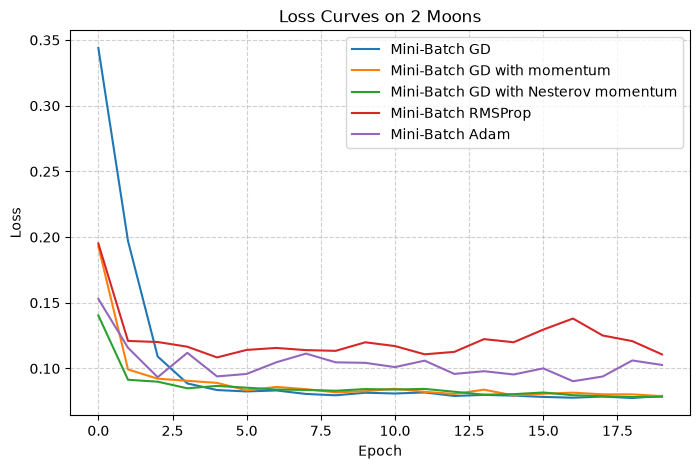

In [53]:
plt.figure(figsize=(8,5))
plt.plot(two_moons_sgd[:20], label="Mini-Batch GD")
plt.plot(two_moons_sgd_momentum[:20], label="Mini-Batch GD with momentum")
plt.plot(two_moons_sgd_momentum_nesterov[:20], label="Mini-Batch GD with Nesterov momentum")
plt.plot(two_moons_rmsprop[:20], label="Mini-Batch RMSProp")
plt.plot(two_moons_adam[:20], label="Mini-Batch Adam")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves on 2 Moons")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

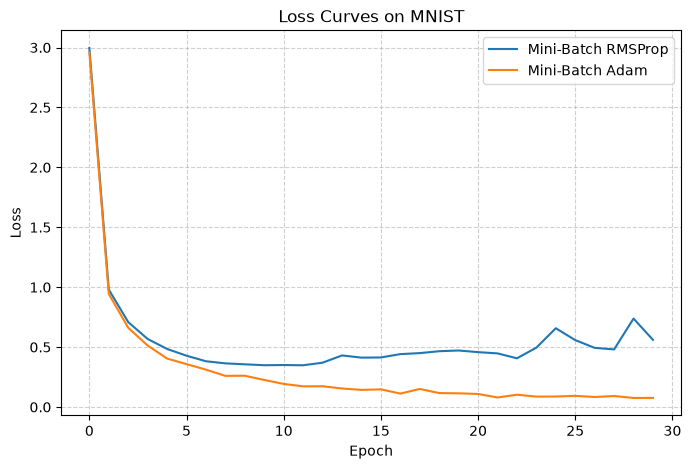

In [54]:
plt.figure(figsize=(8,5))
# plt.plot(MNIST_sgd, label="Mini-Batch GD")
# plt.plot(MNIST_sgd_momentum, label="Mini-Batch GD with momentum")
# plt.plot(MNIST_sgd_momentum_nesterov, label="Mini-Batch GD with Nesterov momentum")
plt.plot(MNIST_rmsprop, label="Mini-Batch RMSProp")
plt.plot(MNIST_adam, label="Mini-Batch Adam")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves on MNIST")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

<a id='RAdam'></a>
# RAdam (Rectified Adam)

[**RAdam** (Liu et al., 2020)](https://arxiv.org/pdf/1908.03265) is a variant of Adam designed to fix the instability of adaptive learning rates in the **early stages of training**.  

<img src="images/math_meme.jpg" alt="Math meme" width="300"/>

## Motivation
- Adam and RMSProp suffer from **large variance in adaptive learning rates** at the start of training.  
- This variance can distort gradients and push optimization into bad local minima.  
- The common workaround is **learning rate warmup**, but it is heuristic and requires tuning.  
- RAdam introduces a **rectification term** to automatically stabilize the variance without requiring warmup.  

---

## Formulation

Adam maintains moving averages of first and second moments:

$ m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t $  
$ v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2 $

Bias-corrected versions:

$ \hat{m}_t = \frac{m_t}{1-\beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1-\beta_2^t} $

---

## Rectification
RAdam introduces a **rectification term $r_t$** based on the variance of the adaptive learning rate:

$ r_t = \sqrt{\frac{(\rho_t - 4)(\rho_t - 2)\rho_\infty}{(\rho_\infty - 4)(\rho_\infty - 2)\rho_t}} $

where:
- $\rho_t$ is the estimated length of the Simple Moving Average (SMA).  
- $\rho_\infty = \frac{2}{1-\beta_2} - 1$ is the maximum possible SMA length.  

---

## Update Rule

At each step $t$, RAdam proceeds as follows:

**1. Gradient**  
$ g_t = \nabla_\theta f_t(\theta_{t-1}) $

**2. Moving Averages**  
- First moment (mean):  
$ m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t $  

- Second moment (variance):  
$ v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2 $

**3. Bias Correction**  
$ \hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t} $

**4. Effective Moving Average Length**  
$ \rho_\infty = \frac{2}{1 - \beta_2} - 1 $  

$ \rho_t = \rho_\infty - \frac{2t \beta_2^t}{1 - \beta_2^t} $

**5. Variance Rectification**  
If $ \rho_t > 4 $:  

- Adaptive LR factor:  
$ l_t = \sqrt{\frac{1 - \beta_2^t}{\hat{v}_t}} $  

- Rectification term:  
$ r_t = \sqrt{\frac{(\rho_t - 4)(\rho_t - 2)\rho_\infty}{(\rho_\infty - 4)(\rho_\infty - 2)\rho_t}} $  

---

### Parameter Update (Piecewise)

- **If $ \rho_t > 4 $** (rectified Adam):  
$ \theta_t = \theta_{t-1} - \alpha \cdot r_t \cdot l_t \cdot \hat{m}_t $

- **Else** (early steps, fallback to SGD+Momentum):  
$ \theta_t = \theta_{t-1} - \alpha \cdot \hat{m}_t $


<!-- - If $\rho_t > 4$ (variance is tractable):

$ \theta_{t+1} = \theta_t - \alpha \cdot r_t \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} $

- Otherwise (early stage, unstable variance):

$ \theta_{t+1} = \theta_t - \alpha \cdot \hat{m}_t $

This effectively **degenerates to SGD with momentum** in the very first iterations.   -->

---

## Advantages
- Removes the need for heuristic warmup schedules.  
- Stabilizes training in the early stages by rectifying variance.  
- More **robust to choice of learning rate** compared to Adam.  

---

## Drawbacks
- Slightly slower start than vanilla Adam (since it rectifies early updates).  
- Still does not always outperform SGD in terms of generalization on some datasets (e.g., ImageNet).  
- Adds some theoretical complexity (rectification computation).  

---

## Practical Defaults
- Same defaults as Adam:  
  - $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\epsilon = 10^{-8}$  
- No need for warmup length parameter (handled internally).  

![Image Title](images/radam.png)
*Taken from [ON THE VARIANCE OF THE ADAPTIVE LEARNING RATE AND BEYOND](https://arxiv.org/pdf/1908.03265)*

In [ ]:
## Example of Mini-Batch with RAdam

two_moons_radam, two_moons_radam_grad = train_two_moons(
    optimizer=torch.optim.RAdam,
    optimizer_params=dict(lr=0.1, betas=(0.9, 0.999))
)
MNIST_radam, MNIST_radam_grad = train_MNIST(
    optimizer=torch.optim.RAdam,
    optimizer_params=dict(lr=0.001, betas=(0.9, 0.999))
)

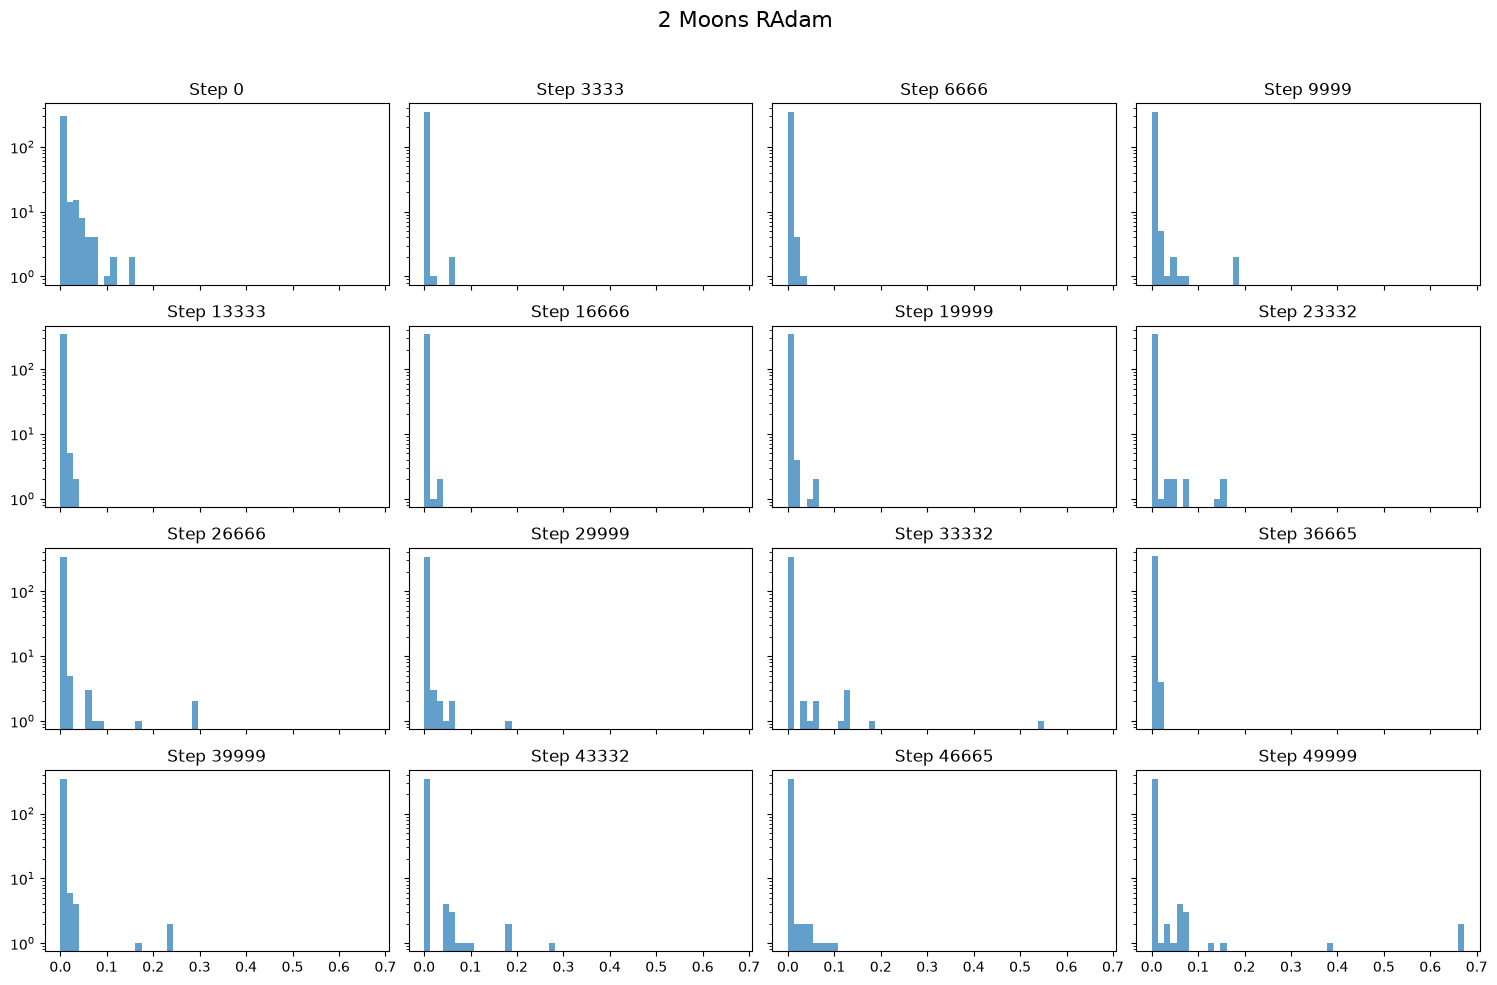

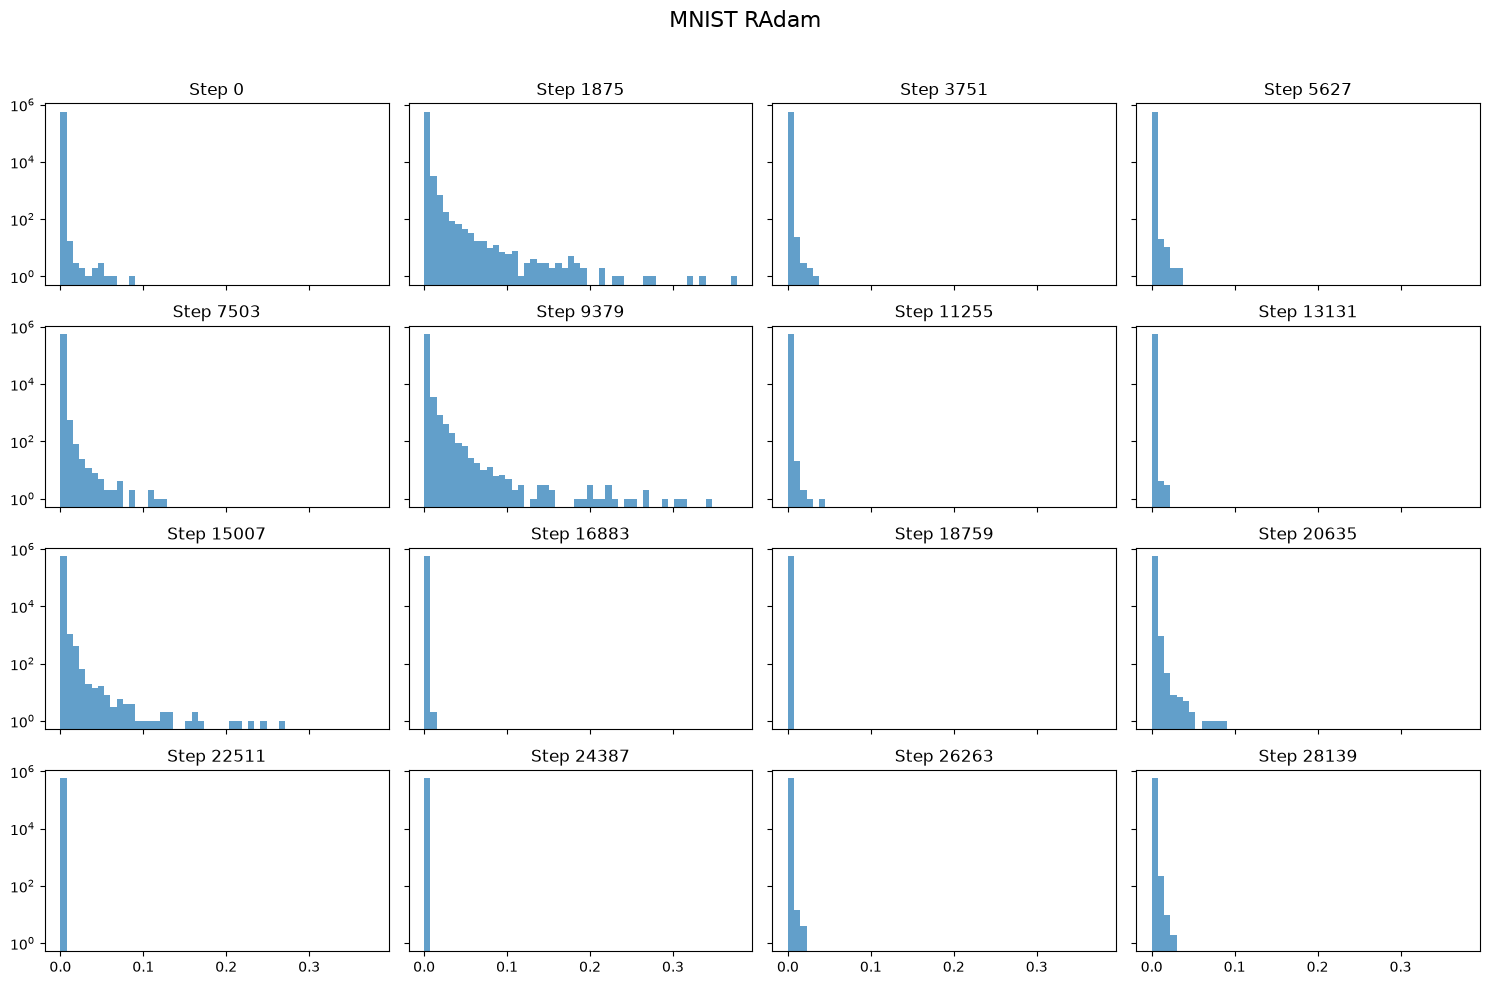

In [55]:
plot_gradient_hist_grid(two_moons_radam_grad, max_plots=16, title="2 Moons RAdam")
plot_gradient_hist_grid(MNIST_radam_grad, max_plots=16, title="MNIST RAdam")

In [63]:
del two_moons_radam_grad, MNIST_radam_grad
gc.collect()

0

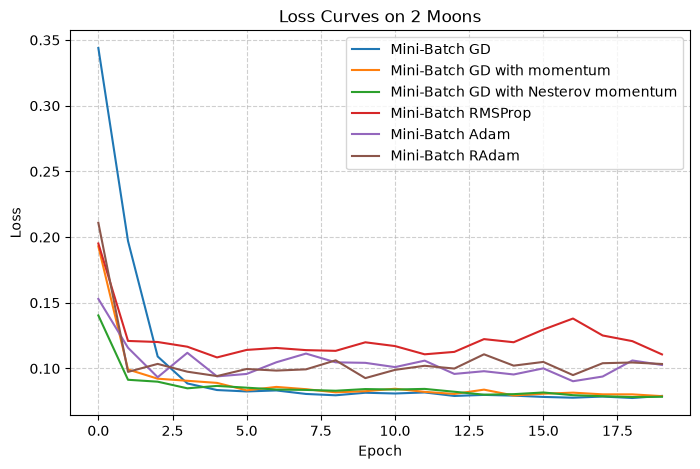

In [56]:
plt.figure(figsize=(8,5))
plt.plot(two_moons_sgd[:20], label="Mini-Batch GD")
plt.plot(two_moons_sgd_momentum[:20], label="Mini-Batch GD with momentum")
plt.plot(two_moons_sgd_momentum_nesterov[:20], label="Mini-Batch GD with Nesterov momentum")
plt.plot(two_moons_rmsprop[:20], label="Mini-Batch RMSProp")
plt.plot(two_moons_adam[:20], label="Mini-Batch Adam")
plt.plot(two_moons_radam[:20], label="Mini-Batch RAdam")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves on 2 Moons")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

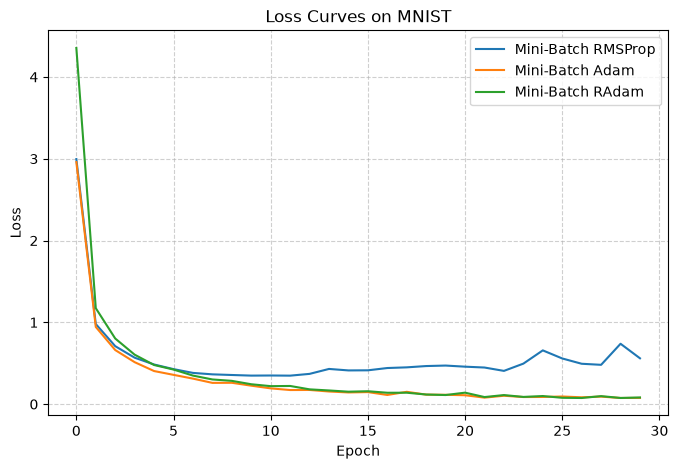

In [57]:
plt.figure(figsize=(8,5))
# plt.plot(MNIST_sgd, label="Mini-Batch GD")
# plt.plot(MNIST_sgd_momentum, label="Mini-Batch GD with momentum")
# plt.plot(MNIST_sgd_momentum_nesterov, label="Mini-Batch GD with Nesterov momentum")
plt.plot(MNIST_rmsprop, label="Mini-Batch RMSProp")
plt.plot(MNIST_adam, label="Mini-Batch Adam")
plt.plot(MNIST_radam, label="Mini-Batch RAdam")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves on MNIST")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

> **PROVE**: Check which optimizsers' direction is a theoretical **descent direction**